<h1 style="color: #1E90FF; font-size: 2.5em; font-weight: bold;">
    FIFA 21 Player Market Value Prediction
</h1>


**Group 10**
- Bárbara Franco (20250388)
- Catarina Mendinhas (20250422)
- Maria Miguel Fonseca (20250380)
- Rodrigo Santos (20250387)
- Rodrigo Teixeira (20250393)

**GitHub repository:**  https://github.com/mariamiguel720/Big-Data-Analytics-Project-25-26

### <font color='#1E90FF'>**Table of Contents**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Import libraries and Set up](#2)
- [3. Load Data](#3)
- [4. MetaData](#4)
- [5. Exploratory Data Analysis](#5)
    - [5.1. Check Data Types](#5_1)
    - [5.2. Check Missing Values](#5_2)
    - [5.3. Check for Duplicates](#5_3)
    - [5.4. Check Unique Values](#5_4)
- [6. Data Preparation](#6)
    - [6.1. Data Preprocessing](#6_1)
        - [6.1.1. Removing Useless Columns](#6_1_1)
        - [6.1.2. Renaming Columns](#6_1_2)
        - [6.1.3. Removing Special Characters and Typecasting](#6_1_3)
        - [6.1.4. Convert Features to Correct Data Type](#6_1_4)
- [7. EDA after Cleaning](#7)
- [8. Feature Engineering](#8)
    - [8.1. Engineered Features Reference](#8_1)
- [9. RDD Analysis — Drivers of Player Market Value](#9)
    - [9.1. Feature–Value Correlations by Position](#9_1)
    - [9.2. Market Outliers — Undervalued & Overvalued Players](#9_2)
    - [9.3. Pre-ML Baseline: OVA Step-Function Predictor](#9_3)
    - [9.4. Age × Position Value Interaction](#9_4)
    - [9.5. Contract Expiry Risk](#9_5)
    - [9.6. Nationality × Position Diversity](#9_6)

<a class="anchor" id="1">

# **1. Project Overview**

[Back to TOC](#toc)
</a>

This notebook covers the full data preparation pipeline for FIFA 21 player data, from raw CSV loading to a clean, analysis-ready Parquet file.

The dataset contains 18,979 players across 77 columns, covering market values, wages, technical attributes, physical measurements, and contract information. Everything is ingested and processed with PySpark, which gives us a unified API for large-scale data processing and machine learning without ever leaving the distributed computing environment.

The work is structured around three phases. First, **Exploratory Data Analysis** examines the raw data to understand its shape and spot missing values, duplicates, and format inconsistencies. Second, **Data Preprocessing** cleans and type-casts all columns, normalises measurement units (heights from feet/inches to cm, weights from lbs to kg, monetary values from K/M notation to actual integers), and handles special characters. Third, **Feature Engineering** creates new informative columns from raw fields and saves the result as a Parquet file for downstream notebooks.

<a class="anchor" id="2">

# **2. Import libraries and Set up**

[Back to TOC](#toc)
</a>

In [2]:
!pip install pyspark plotly "pandas>=2.2.0" "nbformat>=4.2.0"

In [3]:
# Install Java 17 (Required for Spark)
!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless
!java -version

Get:1 https://download.docker.com/linux/ubuntu noble InRelease [48.5 kB]
Hit:2 https://cli.github.com/packages stable InRelease                         
Hit:3 https://packages.cloud.google.com/apt cloud-sdk InRelease                
Hit:4 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease          
Get:5 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:6 https://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]     
Get:7 https://archive.ubuntu.com/ubuntu noble InRelease [256 kB]               
Get:8 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:9 https://download.docker.com/linux/ubuntu noble/stable amd64 Packages [68.5 kB]
Get:10 http://deb.wakemeops.com/wakemeops stable InRelease [50.5 kB]           
Get:11 https://cloud.archive.ubuntu.com/ubuntu noble InRelease [256 kB]        
Get:12 https://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]      
Get:13 https://archive.ubu

In [4]:
import sqlite3
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace, split, when, trim, size,regexp_extract, to_date, year, countDistinct

# Set JAVA_HOME and initialize Spark Session with specific configurations
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"


spark = SparkSession.builder \
        .master("local[4]") \
        .appName("PySpark DataFrames API") \
        .config("spark.executor.memory", "4g") \
        .config("spark.driver.memory", "2g") \
        .getOrCreate()

print("Spark Session configured and ready!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/03 22:16:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Session configured and ready!


<a class="anchor" id="3">

# **3. Load Data**

[Back to TOC](#toc)
</a>

In [5]:
#df = spark.read.csv('./fifa21 raw data v2.csv', header=True, multiLine=True)

In [6]:
df = spark.read.csv('/teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/FIFA/fifa21 raw data v2.csv', header=True, multiLine=True)

The .csv file contains random placed strings (") and "\n". Spark tries to read it but it counts as a new line in wrongfull places.

To correct it, when reading the .csv we added the parameter `multiline = True`.

In [7]:
# Create an alias and cache the DataFrame for downstream transformations
fifa = df.cache()

26/06/03 22:16:44 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


The method .cache() will store the fifa dataset in memory, improving performance by avoiding reloading and recomputing in Spark, allowing it to be accessed across multiple transformations and actions. 

In [8]:
# Cast ID to string for consistent formatting across joins and display 
fifa = fifa.withColumn("ID", col("ID").cast("string"))

<a class="anchor" id="4">

# **4. MetaData**

[Back to TOC](#toc)
</a>

#### Player Identity & Basics
* **ID**: The unique identification number assigned to each player in the database.
* **Name**: The short version of the player's name (e.g., L. Messi).
* **LongName**: The full name of the player.
* **photoUrl**: The web link to the player's profile picture.
* **playerUrl**: The web link to the player's full profile on SoFIFA.
* **Nationality**: The country the player is from.
* **Age**: The player's current age.
* **Club**: The team the player is currently playing for.
* **Contract**: The years remaining on the player's current contract or the contract type.
* **Positions**: All the positions the player is capable of playing.
* **Height**: The player's height (usually in cm).
* **Weight**: The player's weight (usually in kg).
* **Preferred Foot**: The foot (Left or Right) the player prefers to use.
* **Joined**: The exact date the player signed with his current club.
* **Loan Date End**: The date a player's loan period ends (if applicable).

#### Performance Ratings
* **OVA (Overall Rating)**: The general skill level of the player (0-99).
* **POT (Potential)**: The maximum rating the player can reach in his career.
* **BOV (Best Overall)**: The rating the player has in his best specific position.
* **Best Position**: The specific role where the player performs at his highest level.

#### Financial Information
* **Value**: The estimated market value of the player in Euros.
* **Wage**: The weekly salary the player earns at his club.
* **Release Clause**: The amount another club must pay to buy the player instantly.

#### Attacking Attributes
* **Attacking**: The total sum of points of all attacking categories.
* **Crossing**: Accuracy of crosses into the penalty area.
* **Finishing**: Ability to score goals when inside the box.
* **Heading Accuracy**: Accuracy of headers for passes or shots.
* **Short Passing**: Accuracy of short, ground-level passes.
* **Volleys**: Ability to strike the ball while it is in the air.

#### Skill Attributes
* **Skill**: The total sum of points of all technical skill categories.
* **Dribbling**: Ability to control the ball while moving at speed.
* **Curve**: Ability to bend the ball's trajectory (e.g., on free kicks).
* **FK Accuracy**: Accuracy when taking direct free kicks.
* **Long Passing**: Accuracy of long-distance or lobbed passes.
* **Ball Control**: Ability to control the ball instantly when receiving it.

#### Movement Attributes
* **Movement**: The total sum of points of all movement categories.
* **Acceleration**: How quickly a player reaches top speed.
* **Sprint Speed**: The maximum speed the player can reach.
* **Agility**: How quickly a player can change direction.
* **Reactions**: How fast a player responds to a situation happening around them.
* **Balance**: Ability to stay on his feet under physical pressure.

#### Power Attributes
* **Power**: The total sum of points of all physical power categories.
* **Shot Power**: How hard the player can kick the ball.
* **Jumping**: How high the player can jump for headers.
* **Stamina**: How long the player can run before getting tired.
* **Strength**: Physical power to push off opponents.
* **Long Shots**: Ability to score from outside the penalty area.

#### Mentality Attributes
* **Mentality**: The total sum of points of all mental categories.
* **Aggression**: The frequency and intensity of physical challenges and tackles.
* **Interceptions**: Ability to read the game and cut off opponent passes.
* **Positioning**: Ability to find open space on the field.
* **Vision**: Ability to see teammates' runs and execute difficult passes.
* **Penalties**: Accuracy and composure when taking penalty kicks.
* **Composure**: Ability to perform well under pressure from defenders.

#### Defending Attributes
* **Defending**: The total sum of points of all defensive categories.
* **Marking**: Ability to stay close to and track an opponent.
* **Standing Tackle**: Ability to take the ball away while standing.
* **Sliding Tackle**: Ability to take the ball away using a slide.

#### Goalkeeping Attributes
* **Goalkeeping**: The total sum of points of all goalkeeper skills.
* **GK Diving**: Ability to reach for the ball while jumping.
* **GK Handling**: Ability to catch and hold onto the ball.
* **GK Kicking**: Accuracy and distance of goal kicks.
* **GK Positioning**: Ability to stand in the right place to cover the goal.
* **GK Reflexes**: How fast the keeper reacts to close-range shots.

#### Playing Style & Summary Stats
* **Total Stats**: The sum of all individual attribute points of the player.
* **Base Stats**: The sum of the six main face-card attributes (Pace, Shooting, Passing, Dribbling, Defense, Physical).
* **W/F (Weak Foot)**: Performance with the non-dominant foot (1-5 stars).
* **SM (Skill Moves)**: Ability to perform dribbling tricks (1-5 stars).
* **A/W (Attacking Work Rate)**: Effort level in attack (Low/Medium/High).
* **D/W (Defensive Work Rate)**: Effort level in defense (Low/Medium/High).
* **IR (International Reputation)**: Global fame level (1-5 stars).
* **PAC (Pace)**: Overall speed rating.
* **SHO (Shooting)**: Overall scoring rating.
* **PAS (Passing)**: Overall playmaking rating.
* **DRI (Dribbling)**: Overall ball-carrying rating.
* **DEF (Defending)**: Overall defensive rating.
* **PHY (Physical)**: Overall physical presence rating.

#### Other
* **Hits**: Number of views or searches for the player on the platform.

<a class="anchor" id="5">

# **5. Exploratory Data Analysis**

[Back to TOC](#toc)
</a>

In [9]:
n_rows = fifa.count()
n_cols = len(fifa.columns)

print(f"Rows: {n_rows}")
print(f"Columns: {n_cols}")

Rows: 18979
Columns: 77


In [10]:
fifa.printSchema()

root
 |-- ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- LongName: string (nullable = true)
 |-- photoUrl: string (nullable = true)
 |-- playerUrl: string (nullable = true)
 |-- Nationality: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- ↓OVA: string (nullable = true)
 |-- POT: string (nullable = true)
 |-- Club: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- Positions: string (nullable = true)
 |-- Height: string (nullable = true)
 |-- Weight: string (nullable = true)
 |-- Preferred Foot: string (nullable = true)
 |-- BOV: string (nullable = true)
 |-- Best Position: string (nullable = true)
 |-- Joined: string (nullable = true)
 |-- Loan Date End: string (nullable = true)
 |-- Value: string (nullable = true)
 |-- Wage: string (nullable = true)
 |-- Release Clause: string (nullable = true)
 |-- Attacking: string (nullable = true)
 |-- Crossing: string (nullable = true)
 |-- Finishing: string (nullable = true)
 |-- Heading

In [11]:
fifa.show(20)

+------+-----------------+--------------------+--------------------+--------------------+-----------+---+----+---+--------------------+-----------+----------+------+------+--------------+---+-------------+------------+-------------+-------+-----+--------------+---------+--------+---------+----------------+-------------+-------+-----+---------+-----+-----------+------------+------------+--------+------------+------------+-------+---------+-------+-----+----------+-------+-------+--------+----------+---------+----------+-------------+-----------+------+---------+---------+---------+-------+---------------+--------------+-----------+---------+-----------+----------+--------------+-----------+-----------+----------+---+---+------+------+---+---+---+---+---+---+---+----+
|    ID|             Name|            LongName|            photoUrl|           playerUrl|Nationality|Age|↓OVA|POT|                Club|   Contract| Positions|Height|Weight|Preferred Foot|BOV|Best Position|      Joined|Loan 

By analysing some rows, we can already see some inconsistencies:

- `Club`: in the beggining of every cell in this column, there are a lot of "\n" which correspond to spaces which have no meaning in this case. We'll remove it.

- `Contract`: In this feature, there are two dates separated by a "~" for each contract which we assume that it corresponds to the beggining and end date of every player in said club. We will separate the column in two, one for the year of entering the club and other for termination of contract.

- `Positions`: It would be interesting to have a new column based on this one to count the number of positions each player has since some of them has more than one position.

- `Height and Weight`: in each of the columns there are more than one measurement systems, cm and inches or kg and lbs. This will all be converted to the european measurements: cm and kg.

- `Loan Date End`: it has a lot of "NULL". We have to check if it's missing values or strings with "NULL".

- `Value, Wage and Release Clause`: has "$" sign, "K" for thousands and "M" for million. We'll turn this into only numeric column.

- `W/F, SM and IR`: these features have stars after every number because it was extracted from the website of fifa. They will be removed.

Since we have so many columns, we will probably drop some if they have redundant information.

In [12]:
numeric_cols = [
    col_name
    for col_name, dtype in fifa.dtypes
    if dtype in ['int', 'bigint', 'double', 'float', 'long', 'decimal']
]

In [13]:
# At this stage all features are still strings, so we inspect the full summary including non-numeric columns
fifa.summary().show()

26/06/03 22:17:03 WARN DAGScheduler: Broadcasting large task binary with size 1141.8 KiB


+-------+------------------+-----------+--------------------+--------------------+--------------------+-----------+------------------+-----------------+------------------+--------------------+--------------------+---------+------+------+--------------+-----------------+-------------+-----------+-------------+-----+-----+--------------+------------------+-----------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+-------

Since some players have "No Club", we can analyse inconsistencies in `Contract` or if they are interesting for our analysis or not. Also in name fields some players have special carachters. It may be because some players may be from different countries with letters that don't belong to our alphabet.

In [14]:
# show the distribution of values in "Value" for players who have "No Club"
fifa.filter(col("Club") == "No Club").select("Value", "Contract").distinct().show()

+-----+--------+
|Value|Contract|
+-----+--------+
|   €0|    Free|
+-----+--------+



All players without Club have no current value and contract is "Free" as expected

<a class="anchor" id="5_1">

## **5.1. Check Data Types**

[Back to TOC](#toc)
</a>

In [15]:
for col_name, dtype in df.dtypes:
    print(f"{col_name}: {dtype}")

ID: string
Name: string
LongName: string
photoUrl: string
playerUrl: string
Nationality: string
Age: string
↓OVA: string
POT: string
Club: string
Contract: string
Positions: string
Height: string
Weight: string
Preferred Foot: string
BOV: string
Best Position: string
Joined: string
Loan Date End: string
Value: string
Wage: string
Release Clause: string
Attacking: string
Crossing: string
Finishing: string
Heading Accuracy: string
Short Passing: string
Volleys: string
Skill: string
Dribbling: string
Curve: string
FK Accuracy: string
Long Passing: string
Ball Control: string
Movement: string
Acceleration: string
Sprint Speed: string
Agility: string
Reactions: string
Balance: string
Power: string
Shot Power: string
Jumping: string
Stamina: string
Strength: string
Long Shots: string
Mentality: string
Aggression: string
Interceptions: string
Positioning: string
Vision: string
Penalties: string
Composure: string
Defending: string
Marking: string
Standing Tackle: string
Sliding Tackle: string


All features are strings, even the statistic fields which are supposed to be numeric. This will be changed in the next steps to allow for proper analysis and visualization.

<a class="anchor" id="5_2">

## **5.2.  Check Missing Values**

[Back to TOC](#toc)
</a>

In [16]:
# change "NULL" cells to actual null values
fifa = fifa.replace("NULL", None)

In [17]:
from pyspark.sql import functions as F

fifa.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in fifa.columns
]).show()

+---+----+--------+--------+---------+-----------+---+----+---+----+--------+---------+------+------+--------------+---+-------------+------+-------------+-----+----+--------------+---------+--------+---------+----------------+-------------+-------+-----+---------+-----+-----------+------------+------------+--------+------------+------------+-------+---------+-------+-----+----------+-------+-------+--------+----------+---------+----------+-------------+-----------+------+---------+---------+---------+-------+---------------+--------------+-----------+---------+-----------+----------+--------------+-----------+-----------+----------+---+---+---+---+---+---+---+---+---+---+---+----+
| ID|Name|LongName|photoUrl|playerUrl|Nationality|Age|↓OVA|POT|Club|Contract|Positions|Height|Weight|Preferred Foot|BOV|Best Position|Joined|Loan Date End|Value|Wage|Release Clause|Attacking|Crossing|Finishing|Heading Accuracy|Short Passing|Volleys|Skill|Dribbling|Curve|FK Accuracy|Long Passing|Ball Control|

In [18]:
missing_pct = fifa.select([
    (F.count(F.when(F.col(c).isNull(), c)) / F.count("*") * 100).alias(c)
    for c in fifa.columns
])

missing_pct.show(truncate=False)

+---+----+--------+--------+---------+-----------+---+----+---+----+--------+---------+------+------+--------------+---+-------------+------+----------------+-----+----+--------------+---------+--------+---------+----------------+-------------+-------+-----+---------+-----+-----------+------------+------------+--------+------------+------------+-------+---------+-------+-----+----------+-------+-------+--------+----------+---------+----------+-------------+-----------+------+---------+---------+---------+-------+---------------+--------------+-----------+---------+-----------+----------+--------------+-----------+-----------+----------+---+---+---+---+---+---+---+---+---+---+---+------------------+
|ID |Name|LongName|photoUrl|playerUrl|Nationality|Age|↓OVA|POT|Club|Contract|Positions|Height|Weight|Preferred Foot|BOV|Best Position|Joined|Loan Date End   |Value|Wage|Release Clause|Attacking|Crossing|Finishing|Heading Accuracy|Short Passing|Volleys|Skill|Dribbling|Curve|FK Accuracy|Long P

Here we confirm that `Loan Date End` and `Hits` have missing values, 17.966 and 2.595, respectively, which corresponds to 94.66% and 13.67%.

The number of missing values in `Loan Date End` is normal since, a player being loaned to another club isn't so common.

The missing values in `Hits` is also understandeble since it represents the number of visits to the player page in the plaform. Less known players may have never been visited :(

<a class="anchor" id="5_3">

## **5.3.  Check for Duplicates**

[Back to TOC](#toc)
</a>

In [19]:
total_rows = fifa.count()
unique_rows = fifa.dropDuplicates().count()

print("Duplicated rows:", total_rows - unique_rows)

Duplicated rows: 0


There are no duplicates. We are going to check Name duplicates and other specific ones that wouldn't make sense.

In [20]:
fifa.groupBy("LongName") \
    .count() \
    .filter(F.col("count") > 1) \
    .show()

+--------------------+-----+
|            LongName|count|
+--------------------+-----+
|       Michael Smith|    2|
|           Joe Riley|    2|
|      José Hernández|    2|
|     Richard Sánchez|    2|
|        Juan Ramírez|    2|
|          Diego Sosa|    2|
|        Jae Sung Lee|    2|
|       Luis Cárdenas|    2|
|     Alejandro Gómez|    2|
|            Shuai Li|    2|
|Matías de los Santos|    2|
|    Ignacio González|    2|
|  Sebastián Martínez|    2|
|        Adama Traoré|    3|
|        Riku Matsuda|    2|
|   Mathias Jørgensen|    2|
|     Leonardo Castro|    2|
|          Matt Smith|    2|
|         Tae Hee Lee|    2|
|         Greg Taylor|    2|
+--------------------+-----+
only showing top 20 rows


In [21]:
fifa.groupBy("LongName", "Age") \
    .count() \
    .filter(F.col("count") > 1) \
    .show()

+--------------+---+-----+
|      LongName|Age|count|
+--------------+---+-----+
|José Hernández| 23|    2|
|     Peng Wang| 27|    2|
|  Adama Traoré| 25|    2|
|   Alan Medina| 22|    2|
|  Ryan Edwards| 26|    2|
|   Scott Brown| 35|    2|
|    Liam Kelly| 24|    2|
+--------------+---+-----+



In [22]:
fifa.groupBy("LongName", "Age", "Height", "Weight") \
    .count() \
    .filter(F.col("count") > 1) \
    .show()

+--------+---+------+------+-----+
|LongName|Age|Height|Weight|count|
+--------+---+------+------+-----+
+--------+---+------+------+-----+



With this analysis we conclude that some players have the same name, however, they don't correspond to the same players, they have different ages, weights and height.

<a class="anchor" id="5_4">

## **5.4. Check Unique Values**

[Back to TOC](#toc)
</a>

In [23]:
fifa.columns

['ID',
 'Name',
 'LongName',
 'photoUrl',
 'playerUrl',
 'Nationality',
 'Age',
 '↓OVA',
 'POT',
 'Club',
 'Contract',
 'Positions',
 'Height',
 'Weight',
 'Preferred Foot',
 'BOV',
 'Best Position',
 'Joined',
 'Loan Date End',
 'Value',
 'Wage',
 'Release Clause',
 'Attacking',
 'Crossing',
 'Finishing',
 'Heading Accuracy',
 'Short Passing',
 'Volleys',
 'Skill',
 'Dribbling',
 'Curve',
 'FK Accuracy',
 'Long Passing',
 'Ball Control',
 'Movement',
 'Acceleration',
 'Sprint Speed',
 'Agility',
 'Reactions',
 'Balance',
 'Power',
 'Shot Power',
 'Jumping',
 'Stamina',
 'Strength',
 'Long Shots',
 'Mentality',
 'Aggression',
 'Interceptions',
 'Positioning',
 'Vision',
 'Penalties',
 'Composure',
 'Defending',
 'Marking',
 'Standing Tackle',
 'Sliding Tackle',
 'Goalkeeping',
 'GK Diving',
 'GK Handling',
 'GK Kicking',
 'GK Positioning',
 'GK Reflexes',
 'Total Stats',
 'Base Stats',
 'W/F',
 'SM',
 'A/W',
 'D/W',
 'IR',
 'PAC',
 'SHO',
 'PAS',
 'DRI',
 'DEF',
 'PHY',
 'Hits']

In [24]:
def show_unique_values(df, max_values=10):
    """
    Displays the unique values of each column in the DataFrame.
    For columns with many unique values, limits the output to 'max_values'.
    
    Parameters:
        df (DataFrame): Input Spark DataFrame.
        max_values (int): Maximum number of unique values to display per column.
    """
    for column in df.columns:
        print(f"Unique values for column: {column}")
        
        # Count distinct values (wraps the column name in backticks to handle special characters)
        unique_count = df.agg(countDistinct(col(f"`{column}`")).alias("unique_count")) \
                         .collect()[0]["unique_count"]
        print(f"Total unique values: {unique_count}")
        
        # Get a sample of distinct values
        rows = df.select(col(f"`{column}`")).distinct().limit(max_values).collect()
        unique_values = [row[0] for row in rows]   # using index 0 is safer than row[column]
        
        print(f"Sample of unique values (up to {max_values}): {unique_values}")
        print("-" * 40)

show_unique_values(fifa, max_values=10)

Unique values for column: ID


Total unique values: 18979
Sample of unique values (up to 10): ['205069', '193105', '203605', '234035', '189280', '205346', '188942', '247030', '241854', '222457']
----------------------------------------
Unique values for column: Name
Total unique values: 17920
Sample of unique values (up to 10): ['M. Politano', 'A. Saint-Maximin', 'G. Xhaka', 'A. Izzo', 'Postigo', 'G. Schennikov', 'F. Jara', 'R. Assalé', 'C. Adams', 'J. Castelletto']
----------------------------------------
Unique values for column: LongName
Total unique values: 18852
Sample of unique values (up to 10): ['Kenny Lala', 'Víctor Machín Pérez', 'Bouna Sarr', 'Lucas Castro', 'Anwar El Ghazi', 'Rúben Afonso Borges Semedo', 'Jawad El Yamiq', 'Jacob Bruun Larsen', 'Gérson Adriano Damesio Figueiras', 'Ezequiel Unsain']
----------------------------------------
Unique values for column: photoUrl
Total unique values: 18979
Sample of unique values (up to 10): ['https://cdn.sofifa.com/players/209/331/21_60.png', 'https://cdn.sofif

In [25]:
categorical_cols = [
    c for c, t in fifa.dtypes
    if t == "string"
]

for c in categorical_cols:
    print(f"\nValue counts for: {c}")

    fifa.groupBy(c) \
        .count() \
        .orderBy(F.desc("count")) \
        .show(10, truncate=False)


Value counts for: ID


+------+-----+
|ID    |count|
+------+-----+
|205069|1    |
|193105|1    |
|203605|1    |
|234035|1    |
|189280|1    |
|205346|1    |
|188942|1    |
|247030|1    |
|241854|1    |
|222457|1    |
+------+-----+
only showing top 10 rows

Value counts for: Name
+------------+-----+
|Name        |count|
+------------+-----+
|J. Rodríguez|13   |
|Paulinho    |8    |
|A. González |7    |
|J. García   |7    |
|R. Fernández|7    |
|M. Smith    |7    |
|J. Jones    |7    |
|J. González |7    |
|J. Williams |6    |
|J. Rojas    |6    |
+------------+-----+
only showing top 10 rows

Value counts for: LongName
+--------------------+-----+
|LongName            |count|
+--------------------+-----+
|Adama Traoré        |3    |
|Nicolás González    |3    |
|Danny Rose          |3    |
|Peng Wang           |3    |
|Diego Rodríguez     |3    |
|Liam Kelly          |3    |
|Michael Smith       |2    |
|Matías de los Santos|2    |
|Joe Riley           |2    |
|José Hernández      |2    |
+----------------

<a class="anchor" id="6">

# **6.  Data Preparation**

[Back to TOC](#toc)
</a>

<a class="anchor" id="6_1">

## **6.1. Data Preprocessing**

[Back to TOC](#toc)
</a>

<a class="anchor" id="6_1_1">

### **6.1.1. Removing Useless Columns**

[Back to TOC](#toc)
</a>

Firstly, we will be dropping the columns `photoUrl` and `playerUrl` as it gives us no usefull information.

In [26]:
fifa = fifa.drop("Name","photoUrl", "playerUrl")

<a class="anchor" id="6_1_2">

### **6.1.2. Renaming Columns**

[Back to TOC](#toc)
</a>

Here, after droping the column `Name`, we rename the column `LongName` to Name and also rename the `OVA` one.

In [27]:
fifa = fifa.withColumnRenamed("LongName", "Name")
fifa = fifa.withColumnRenamed("↓OVA", "OVA")

Special carachters in Spark are not the optimum so, for all spaces and special symbols we'll replace by an "_".

In [28]:
rename_map = {
    "Heading Accuracy": "Heading_Accuracy",
    "Short Passing": "Short_Passing",
    "Ball Control": "Ball_Control",
    "Sprint Speed": "Sprint_Speed",
    "Shot Power": "Shot_Power",
    "Long Shots": "Long_Shots",
    "Long Passing": "Long_Passing",
    "FK Accuracy": "FK_Accuracy",
    "Standing Tackle": "Standing_Tackle",
    "Sliding Tackle": "Sliding_Tackle",
    "GK Diving": "GK_Diving",
    "GK Handling": "GK_Handling",
    "GK Kicking": "GK_Kicking",
    "GK Positioning": "GK_Positioning",
    "GK Reflexes": "GK_Reflexes",
    "Total Stats": "Total_Stats",
    "Base Stats": "Base_Stats",
    "Preferred Foot": "Preferred_Foot",
    "Best Position": "Best_Position",
    "Release Clause": "Release_Clause",
    "W/F": "Weak_Foot",
    "SM": "Skill_Moves",
    "A/W": "Attack_Workrate",
    "D/W": "Defense_Workrate",
    "IR": "Intl_Reputation",
}
for old, new in rename_map.items():
    fifa = fifa.withColumnRenamed(old, new)

<a class="anchor" id="6_1_3">

### **6.1.3. Removing Special Characters and Typecasting**

[Back to TOC](#toc)
</a>

The `Club` column has invalid characters such as \n, here we will remove them.

In [29]:
fifa = fifa.withColumn("Club", trim(regexp_replace(col("Club"), r"[\n]", "")))

In this step, we are normalizing all `Height` values to the metric system (cm) and converting the data type from string to integer.

In [30]:
fifa = fifa.withColumn("Height", 
    when(col("Height").contains("'"), 
        (split(col("Height"), "'")[0].cast("float") * 30.48) + 
        (regexp_replace(split(col("Height"), "'")[1], '"', "").cast("float") * 2.54)
    ).otherwise(regexp_replace(col("Height"), "cm", "").cast("float"))
).withColumn("Height", col("Height").cast("int"))

We will do the same for the `Weight` values.

In [31]:
fifa = fifa.withColumn("Weight", 
    when(col("Weight").contains("lbs"), 
        (regexp_replace(col("Weight"), "lbs", "").cast("float") * 0.453592)
    ).otherwise(regexp_replace(col("Weight"), "kg", "").cast("float"))
).withColumn("Weight", col("Weight").cast("int"))

Columns like `Value`, `Wage`, and `Hits` contain symbols ('€') and abbreviations ('M', 'K'). We apply a custom `parse_multipliers` function to clean the strings, calculate the final numerical values, and convert them to integers.

In [32]:
def parse_multipliers(column_name):
    return when(col(column_name).contains("M"), 
                (regexp_replace(col(column_name), "[€|M]", "").cast("float") * 1000000)) \
          .when(col(column_name).contains("K"), 
                (regexp_replace(col(column_name), "[€|K]", "").cast("float") * 1000)) \
          .otherwise(regexp_replace(col(column_name), "[€]", "").cast("float"))

for c in ["Value", "Wage", "Release_Clause", "Hits"]:
    fifa = fifa.withColumn(c, parse_multipliers(c).cast("int"))

<a class="anchor" id="6_1_4">

### **6.1.4. Convert Features to Correct Data Type**

[Back to TOC](#toc)
</a>

Here we will convert all the simple numeric features from string to integer.

In [33]:
int_cols = [
    'ID', 'Age', 'OVA', 'POT', 'BOV', 'Attacking', 'Crossing', 'Finishing', 'Heading_Accuracy', 'Short_Passing', 'Volleys',
    'Skill', 'Dribbling', 'Curve', 'FK_Accuracy', 'Long_Passing', 'Ball_Control', 'Movement', 'Acceleration', 'Sprint_Speed',
    'Agility', 'Reactions', 'Balance', 'Power', 'Shot_Power', 'Jumping', 'Stamina', 'Strength', 'Long_Shots',
    'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Defending', 'Marking',
    'Standing_Tackle', 'Sliding_Tackle', 'Goalkeeping', 'GK_Diving', 'GK_Handling', 'GK_Kicking', 'GK_Positioning', 'GK_Reflexes',
    'Total_Stats', 'Base_Stats', 'Weak_Foot', 'Skill_Moves',
    'Intl_Reputation', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY'

]

In [34]:
from pyspark.sql.functions import regexp_replace, col, when, length

for c in int_cols:
    cleaned = regexp_replace(col(f"`{c}`"), "[^0-9]", "")
    fifa = fifa.withColumn(
        c,
        when(length(cleaned) == 0, None).otherwise(cleaned).cast("int")
    )

The date-related columns (`Contract`, `Joined`, and `Loan Date End`) are deliberately left as strings at this stage. They require careful parsing that depends on the contract type (permanent, on loan, or free agent) and will be fully handled in Section 8 (Feature Engineering), where they are decomposed into three structured numeric features: `Contract_Status`, `Contract_Start_Year`, and `Contract_End_Year`.

**Cache the dataset again**

In [35]:
fifa = fifa.cache()

<a class="anchor" id="7">

# **7. EDA after Cleaning**

[Back to TOC](#toc)
</a>

**Describe numeric columns**

In [36]:
# get all numeric columns
numeric_cols = [
    col_name
    for col_name, dtype in fifa.dtypes
    if dtype in ['int', 'bigint', 'double', 'float', 'long', 'decimal']
]

In [37]:
fifa.describe(numeric_cols).show()

26/06/03 22:17:58 ERROR CodeGenerator: Failed to compile the generated Java code.
org.codehaus.commons.compiler.InternalCompilerException: Compiling "GeneratedClass" in File 'generated.java', Line 1, Column 1: File 'generated.java', Line 33, Column 14: Compiling "project_doConsume_0(InternalRow inputadapter_row_0, UTF8String project_expr_0_0, boolean project_exprIsNull_0_0, UTF8String project_expr_1_0, boolean project_exprIsNull_1_0, UTF8String project_expr_2_0, boolean project_exprIsNull_2_0, UTF8String project_expr_3_0, boolean project_exprIsNull_3_0, UTF8String project_expr_4_0, boolean project_exprIsNull_4_0, UTF8String project_expr_5_0, boolean project_exprIsNull_5_0, UTF8String project_expr_6_0, boolean project_exprIsNull_6_0, UTF8String project_expr_7_0, boolean project_exprIsNull_7_0, UTF8String project_expr_8_0, boolean project_exprIsNull_8_0, UTF8String project_expr_9_0, boolean project_exprIsNull_9_0, UTF8String project_expr_10_0, boolean project_exprIsNull_10_0, UTF8String 

+-------+------------------+------------------+-----------------+------------------+------------------+-----------------+-----------------+------------------+------------------+-----------------+------------------+-----------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------

From this we can see that some metrics are between 0 and 100 and others from 1 to 5 which corresponds to the ones who previously had stars. `Age` of players seems normal since players usually end their carreers early but there are probably some outliers, 16 is too young and 53 is too old for football players. Other features seem normal.

**Outliers**

In [38]:
# Detect outliers using the IQR method for the Value column
q1, q3 = fifa.approxQuantile("Value", [0.25, 0.75], 0.01)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = fifa.filter((col("Value") < lower) | (col("Value") > upper))
print(f"Number of outliers: {outliers.count()}")

Number of outliers: 2408


We extend the outlier analysis to physical and demographic attributes. For each column, the IQR bounds are computed in a distributed fashion using `approxQuantile`, and the results are visualised as boxplots and histograms. Only aggregated results are collected to the driver for plotting. We won't remove any outliers in this data set since they all represent valid players, like Messi or Ronaldo.

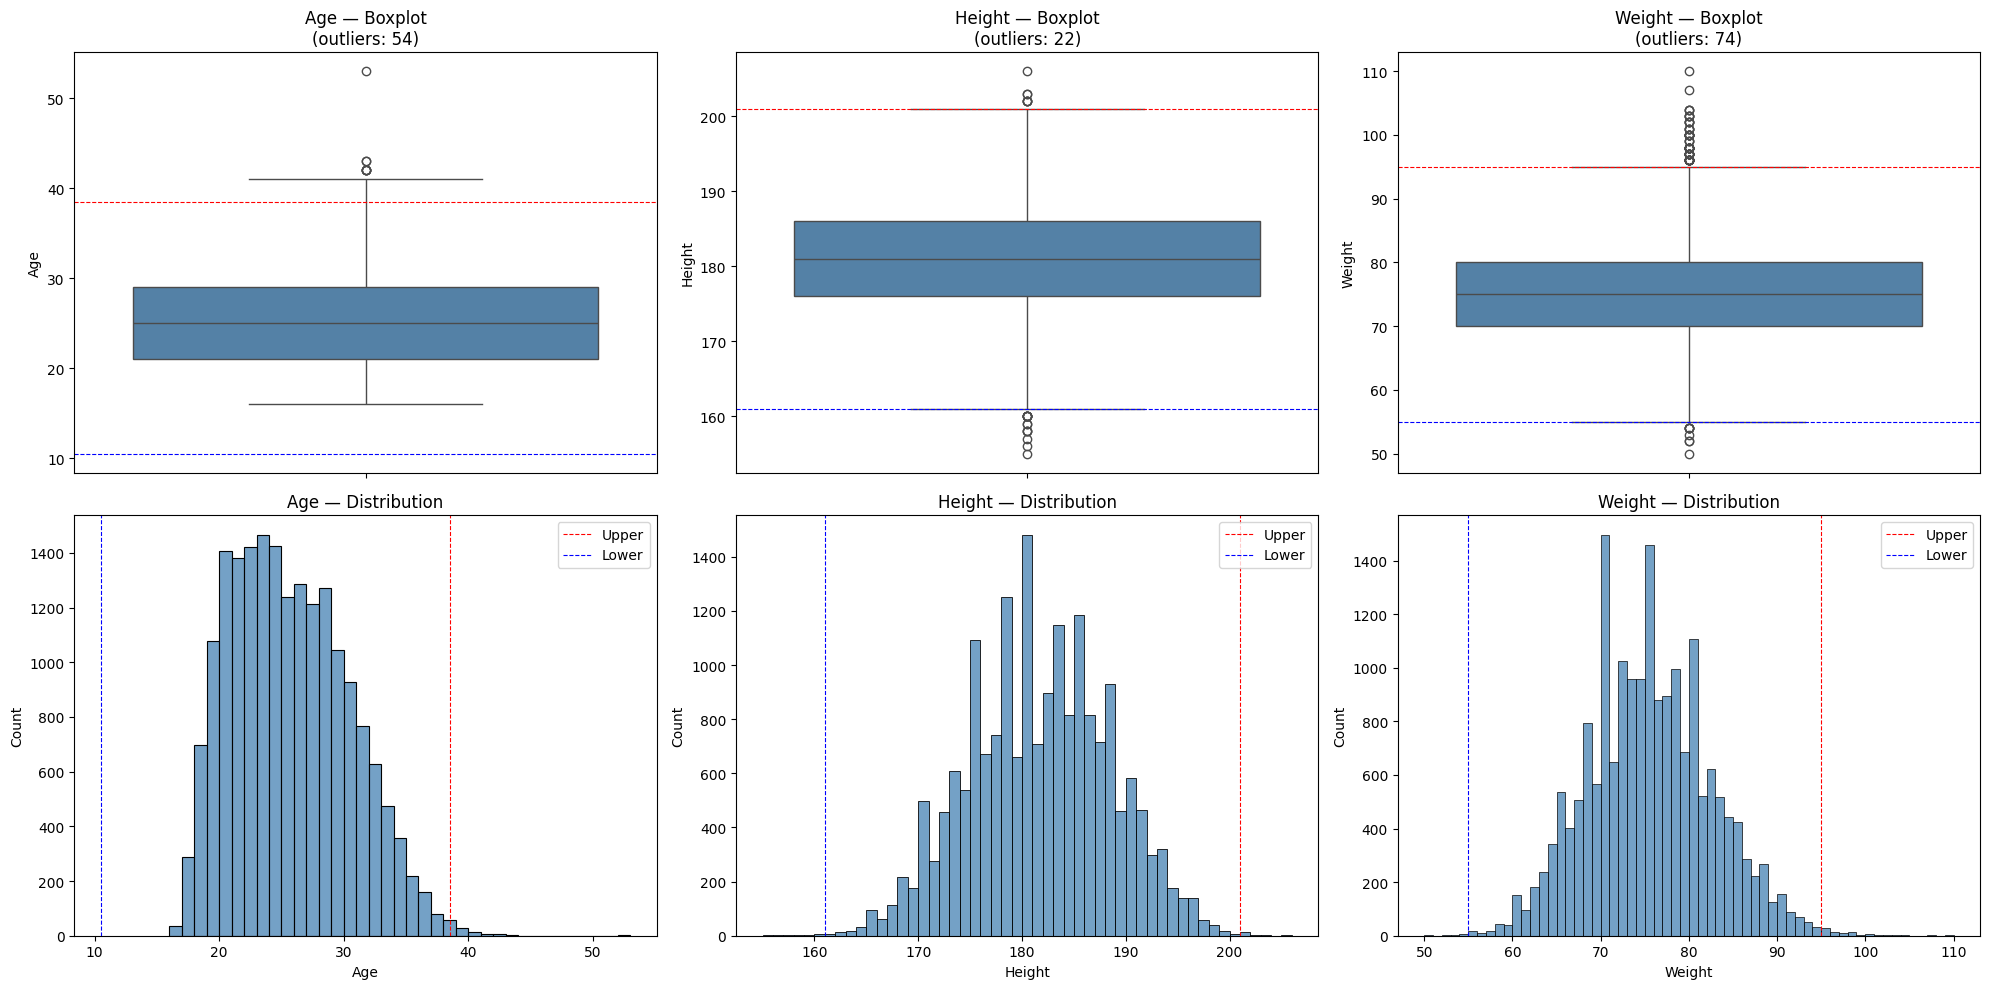

In [39]:
outlier_cols = ["Age", "Height", "Weight"]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for i, c in enumerate(outlier_cols):
    # IQR calculation — big data safe, runs distributed
    q1, q3 = fifa.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = fifa.filter((col(c) < lower) | (col(c) > upper)).count()

    # NOTE: .toPandas() only on single column for visualization
    col_pd = fifa.select(c).filter(col(c).isNotNull()).toPandas()

    # Boxplot
    sns.boxplot(y=col_pd[c], ax=axes[0][i], color="steelblue")
    axes[0][i].axhline(y=upper, color="red", linestyle="--", linewidth=0.8)
    axes[0][i].axhline(y=lower, color="blue", linestyle="--", linewidth=0.8)
    axes[0][i].set_title(f"{c} — Boxplot\n(outliers: {n_outliers})")
    axes[0][i].set_ylabel(c)

    # Histograma
    sns.histplot(col_pd[c], binwidth=1, ax=axes[1][i], color="steelblue")
    axes[1][i].axvline(x=upper, color="red", linestyle="--", linewidth=0.8, label="Upper")
    axes[1][i].axvline(x=lower, color="blue", linestyle="--", linewidth=0.8, label="Lower")
    axes[1][i].set_title(f"{c} — Distribution")
    axes[1][i].set_xlabel(c)
    axes[1][i].legend()

plt.tight_layout()
plt.show()

The same approach is applied to the core analytical variables: `Value`, `OVA`, and `Hits`. The heavily right-skewed nature of `Value` is immediately visible, confirming that a log transformation will be appropriate when this column is used as a regression target.

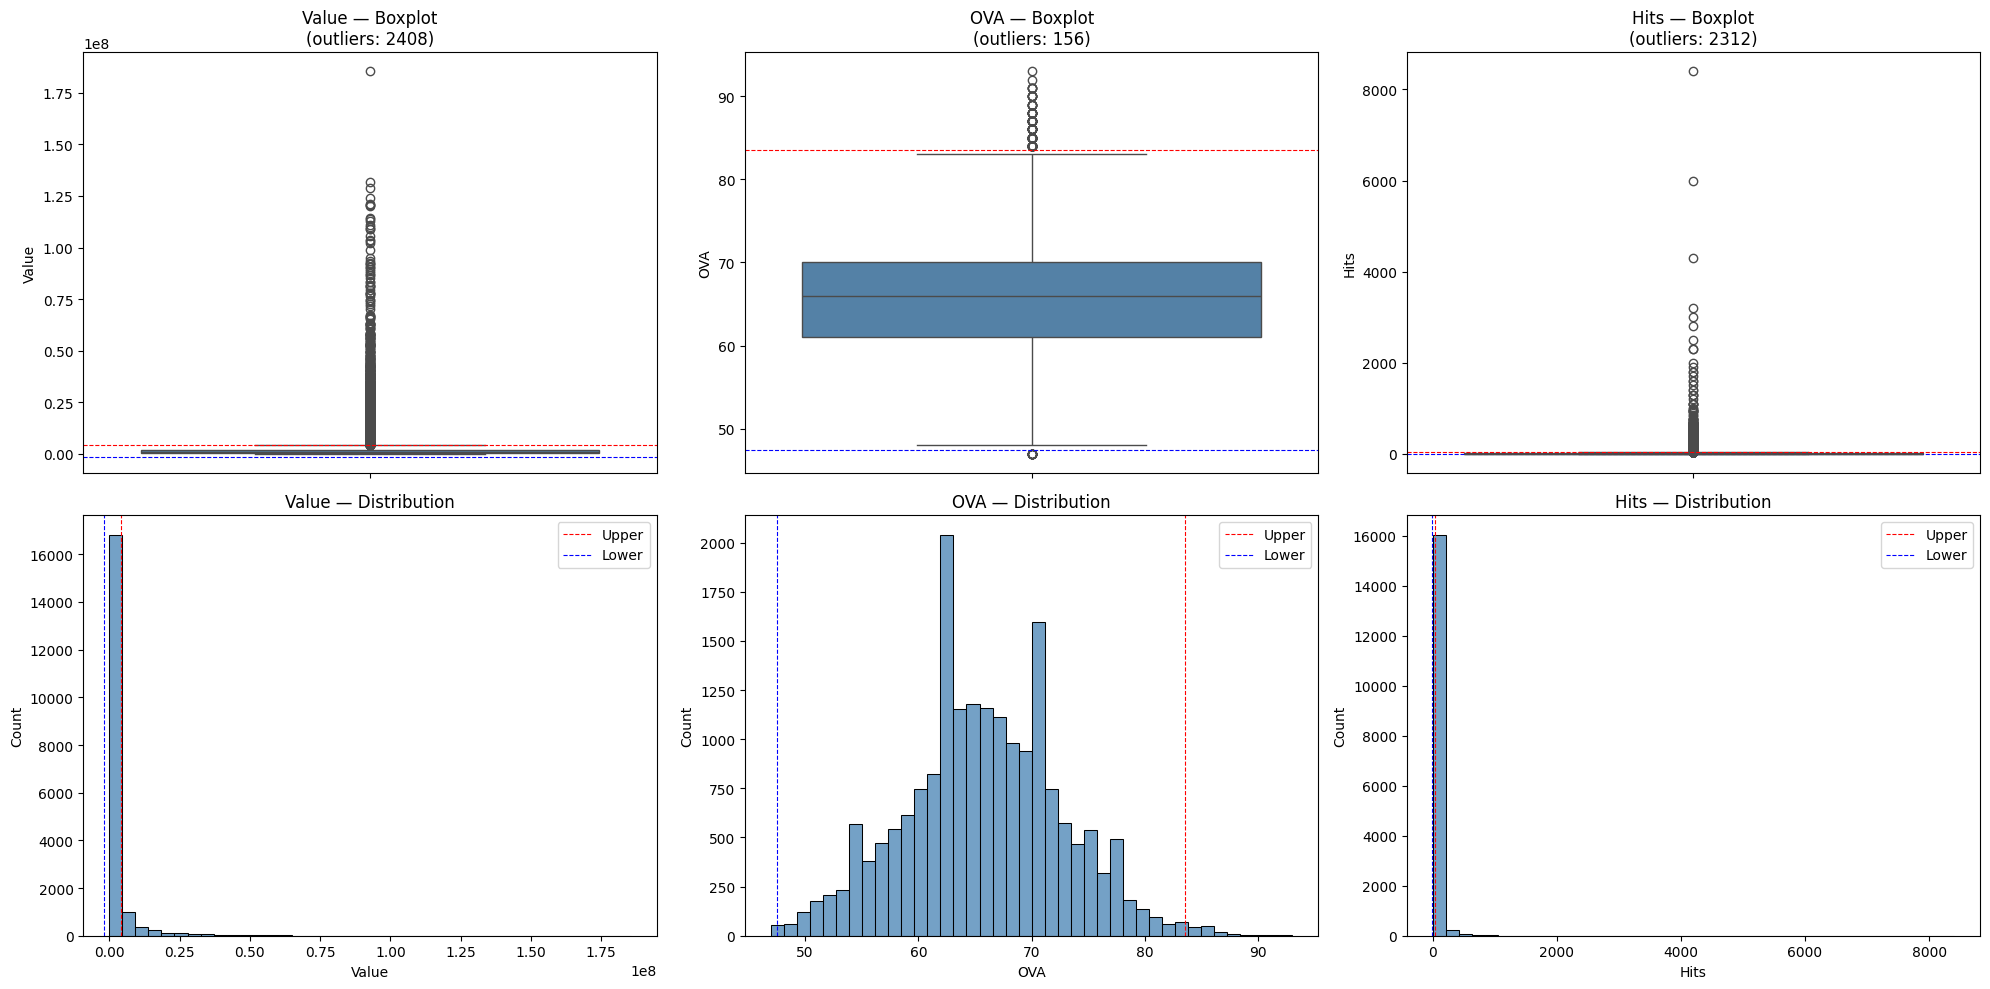

In [40]:
outlier_cols = ["Value", "OVA", "Hits"]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for i, c in enumerate(outlier_cols):
    # IQR calculation — big data safe, runs distributed
    q1, q3 = fifa.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = fifa.filter((col(c) < lower) | (col(c) > upper)).count()

    # NOTE: .toPandas() only on single column for visualization
    col_pd = fifa.select(c).filter(col(c).isNotNull()).toPandas()

    # Boxplot
    sns.boxplot(y=col_pd[c], ax=axes[0][i], color="steelblue")
    axes[0][i].axhline(y=upper, color="red", linestyle="--", linewidth=0.8)
    axes[0][i].axhline(y=lower, color="blue", linestyle="--", linewidth=0.8)
    axes[0][i].set_title(f"{c} — Boxplot\n(outliers: {n_outliers})")
    axes[0][i].set_ylabel(c)

    # Histograma
    sns.histplot(col_pd[c], bins=40, ax=axes[1][i], color="steelblue")
    axes[1][i].axvline(x=upper, color="red", linestyle="--", linewidth=0.8, label="Upper")
    axes[1][i].axvline(x=lower, color="blue", linestyle="--", linewidth=0.8, label="Lower")
    axes[1][i].set_title(f"{c} — Distribution")
    axes[1][i].set_xlabel(c)
    axes[1][i].legend()

plt.tight_layout()
plt.show()

**Correlations**

In [41]:
# features for correlation will be the ones w/o missing values and numeric. From numeric_cols we will remove "Hits" and "End_Loan_Date"
correlation_cols = [c for c in numeric_cols if c not in ["ID", "Hits", "End_Loan_Date"]]

In [42]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

correlation_cols = [c for c, t in fifa.dtypes if t in ('int','double','float','bigint')]

assembler = VectorAssembler(inputCols=correlation_cols, outputCol="features", handleInvalid="skip")
df_vec = assembler.transform(fifa).select("features")

corr_matrix = Correlation.corr(df_vec, "features", method="pearson").head()[0]
corr_array = corr_matrix.toArray()\

import plotly.express as px
import pandas as pd

corr_df = pd.DataFrame(corr_array, index=correlation_cols, columns=correlation_cols)

fig = px.imshow(
    corr_df,
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="Full Correlation Matrix",
)
fig.update_layout(width=1000, height=1000)
fig.show()

26/06/03 22:18:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


<a class="anchor" id="8">

# **8. Feature Engineering**

[Back to TOC](#toc)
</a>

A new feature engineered `N_Positions` to count the total playable positions per player, capturing their versatility.

In [43]:
fifa = fifa.withColumn("N_Positions", size(split(col("Positions"), ",")))

We engineered three new clean features (`Contract_Status`, `Contract_Start_Year`, and `Contract_End_Year`) to replace the messy raw data. The redundant `Contract`, `Joined`, and `Loan Date End` columns were dropped to keep the dataset clean.

In [ ]:
# 1. Categorize contract status
fifa = fifa.withColumn("Contract_Status", 
    when(col("Contract").contains("On Loan"), "On Loan")
    .when(col("Contract").contains("Free"), "Free")
    .otherwise("Permanent")
)

# 2. Extract start year from 'Joined' (Null for 'Free' agents)
fifa = fifa.withColumn("Contract_Start_Year", 
    when(col("Contract_Status") == "Free", None)
    .otherwise(year(to_date(col("Joined"), "MMM d, yyyy")))
)

# 3. Extract end year based on status (Null for 'Free' agents)
fifa = fifa.withColumn("Contract_End_Year",
    when(col("Contract_Status") == "Permanent", trim(split(col("Contract"), "~")[1]).cast("int"))
    .when(col("Contract_Status") == "On Loan", regexp_extract(col("Contract"), r"(\d{4})", 1).cast("int"))
    .otherwise(None)
)

# 4. Drop redundant columns
fifa = fifa.drop("Contract", "Joined", "Loan Date End")

# Validate results
fifa.select("Name", "Contract_Status", "Contract_Start_Year", "Contract_End_Year").show(15, truncate=False)

+---------------------------------+---------------+-------------------+-----------------+
|Name                             |Contract_Status|Contract_Start_Year|Contract_End_Year|
+---------------------------------+---------------+-------------------+-----------------+
|Lionel Messi                     |Permanent      |2004               |2021             |
|C. Ronaldo dos Santos Aveiro     |Permanent      |2018               |2022             |
|Jan Oblak                        |Permanent      |2014               |2023             |
|Kevin De Bruyne                  |Permanent      |2015               |2023             |
|Neymar da Silva Santos Jr.       |Permanent      |2017               |2022             |
|Robert Lewandowski               |Permanent      |2014               |2023             |
|Mohamed Salah                    |Permanent      |2017               |2023             |
|Alisson Ramses Becker            |Permanent      |2018               |2024             |
|Kylian Mb

Loaned players, have Start_Year from original club and End_Year from loaned club

In [45]:
for col_name, dtype in fifa.dtypes:
    print(f"{col_name}: {dtype}")

ID: int
Name: string
Nationality: string
Age: int
OVA: int
POT: int
Club: string
Positions: string
Height: int
Weight: int
Preferred_Foot: string
BOV: int
Best_Position: string
Value: int
Wage: int
Release_Clause: int
Attacking: int
Crossing: int
Finishing: int
Heading_Accuracy: int
Short_Passing: int
Volleys: int
Skill: int
Dribbling: int
Curve: int
FK_Accuracy: int
Long_Passing: int
Ball_Control: int
Movement: int
Acceleration: int
Sprint_Speed: int
Agility: int
Reactions: int
Balance: int
Power: int
Shot_Power: int
Jumping: int
Stamina: int
Strength: int
Long_Shots: int
Mentality: int
Aggression: int
Interceptions: int
Positioning: int
Vision: int
Penalties: int
Composure: int
Defending: int
Marking: int
Standing_Tackle: int
Sliding_Tackle: int
Goalkeeping: int
GK_Diving: int
GK_Handling: int
GK_Kicking: int
GK_Positioning: int
GK_Reflexes: int
Total_Stats: int
Base_Stats: int
Weak_Foot: int
Skill_Moves: int
Attack_Workrate: string
Defense_Workrate: string
Intl_Reputation: int
PAC: 

With preprocessing and feature engineering complete, the cleaned dataset is saved to Parquet format. Parquet uses columnar storage with built-in compression, which makes subsequent reads significantly faster than CSV and, importantly, preserves all the data types we just engineered — something a plain CSV cannot guarantee.

In [46]:
fifa.write.mode("overwrite").parquet("cleaned_fifa.parquet")

<a class="anchor" id="8_1">

## **8.1. Engineered Features Reference**

[Back to TOC](#toc)
</a>

Section 8 produced four new columns and removed the three raw contract columns they were derived from. The entries below document each engineered feature in the same format as Section 4.

#### Contract Information
* **Contract_Status**: The type of arrangement between the player and their current club. Takes one of three values: `Permanent` for standard fixed-term contracts, `On Loan` for players temporarily registered from another club, and `Free` for players without a current club contract. Derived from the raw `Contract` column.
* **Contract_Start_Year**: The calendar year the player joined their current club, extracted from the `Joined` field. Null for free agents, who have no active club relationship to date.
* **Contract_End_Year**: The calendar year the player's current arrangement expires. For permanent contracts this is the end year in the `Contract` field; for loans it is the loan return date. Null for free agents.

#### Player Profile
* **N_Positions**: The total number of positions a player can play, obtained by counting the comma-separated entries in the `Positions` field. A value of 1 indicates a positional specialist; higher values reflect versatility across multiple roles.

#### Removed Columns
The following raw columns were dropped once their information was captured in the features above.

* **Contract**: Raw string encoding the contract period (e.g. `2018 ~ 2023`) or contract status (`On Loan`, `Free`). Replaced by `Contract_Status`, `Contract_Start_Year`, and `Contract_End_Year`.
* **Joined**: Date string recording when the player signed with their current club. Replaced by `Contract_Start_Year`.
* **Loan Date End**: Date string for the end of a loan period. Replaced by `Contract_End_Year` for on-loan players.

<a class="anchor" id="9">

# **9. RDD Analysis — Drivers of Player Market Value**

[Back to TOC](#toc)
</a>

This section moves from Spark's high-level **DataFrame API** to the lower-level **RDD (Resilient Distributed Dataset) API**, applying distributed transformations such as `map`, `filter`, `groupByKey`, `flatMap`, `mapValues`, `sortBy` and `reduce`.

The three analyses below are designed to **complement** — not replicate — the SparkSQL work in Notebook 2. Where SparkSQL aggregates across a single dimension at a time (value *by* position, value *by* age), the RDD API gives fine-grained control to:

- Compute per-**position** feature correlations with `Value` (a global correlation matrix cannot capture positional differences)
- Identify individual players whose market value **deviates significantly** from their peer group
- Build a simple **pre-ML baseline predictor** to benchmark the models in Notebook 3

All analyses filter `Value > 0`, excluding free agents (€0) who are not relevant for market value prediction.

In [48]:
# Convert cleaned DataFrame to RDD — filter out free agents (Value = 0)
rdd = fifa.filter(col("Value") > 0).rdd

print(f"RDD partitions : {rdd.getNumPartitions()}")
print(f"Players with Value > 0 : {rdd.count():,}")

RDD partitions : 1


Players with Value > 0 : 18,731


<a class="anchor" id="9_1">

## **9.1. Feature–Value Correlations by Position**

[Back to TOC](#toc)
</a>

**Question:** Which individual features are most correlated with a player's market value — and does this vary by playing position?

The global Pearson correlation matrix (Section 7) treats all players equally. But a goalkeeper's value is driven by completely different attributes than a striker's. Using RDD's `groupByKey` and `mapValues`, we compute a **per-position Pearson correlation** for each key feature against `Value`.

**RDD operations:** `map` → `filter` → `groupByKey` → `mapValues` (custom Pearson) → `filter` → `collect`

In [49]:
# ── Pearson correlation helper (runs distributed on workers) ──────────────────
def pearson(pairs):
    """Compute Pearson r between two numeric sequences; returns None for small groups."""
    valid = [(x, y) for x, y in pairs if x is not None and y is not None]
    n = len(valid)
    if n < 5:
        return None
    xs, ys = zip(*valid)
    mx, my = sum(xs) / n, sum(ys) / n
    num = sum((x - mx) * (y - my) for x, y in zip(xs, ys))
    den = (sum((x - mx) ** 2 for x in xs) * sum((y - my) ** 2 for y in ys)) ** 0.5
    return round(num / den, 4) if den != 0 else 0.0

# ── Features to correlate against Value ──────────────────────────────────────
# Curated to maximise variation across positions. Composite/colinear features
# (POT, Wage, Total_Stats, BOV, Release_Clause) excluded — they correlate
# ~uniformly across all positions and would flatten the heatmap.
features = [
    # Baseline (universal driver — anchors the colour scale)
    'OVA',
    # Attacking — should peak at ST/CF/W, drop to ~0 for CB/GK
    'Finishing', 'Positioning', 'Long_Shots', 'Heading_Accuracy',
    # Defending — peaks at CB/FB/CDM, ~0 for ST/W/GK
    'Marking', 'Interceptions',
    # Goalkeeping — signal only at GK, zero everywhere else (clearest visual test)
    'GK_Reflexes',
    # Playmaking / passing — peaks at CM/CAM, mid for W, low for CB/ST
    'Vision', 'Short_Passing', 'Crossing',
    # Technical
    'Dribbling',
    # Physical
    'Sprint_Speed', 'Strength', 'Composure',
    # Market / brand (not a skill — shows where reputation drives value)
    'Intl_Reputation',
]

# For each feature: map to (position, (feat_val, value)) → groupByKey → Pearson
corr_results = {}
for feat in features:
    corr_by_pos = (
        rdd
        .map(lambda r, f=feat: (r["Best_Position"], (r[f], r["Value"])))
        .filter(lambda x: x[1][0] is not None and x[1][1] is not None)
        .groupByKey()
        .mapValues(lambda pairs: pearson(list(pairs)))
        .filter(lambda x: x[1] is not None)
        .collect()
    )
    corr_results[feat] = dict(corr_by_pos)

print(f"Correlations computed for {len(features)} features across "
      f"{len(next(iter(corr_results.values())))} positions.")

Correlations computed for 16 features across 15 positions.


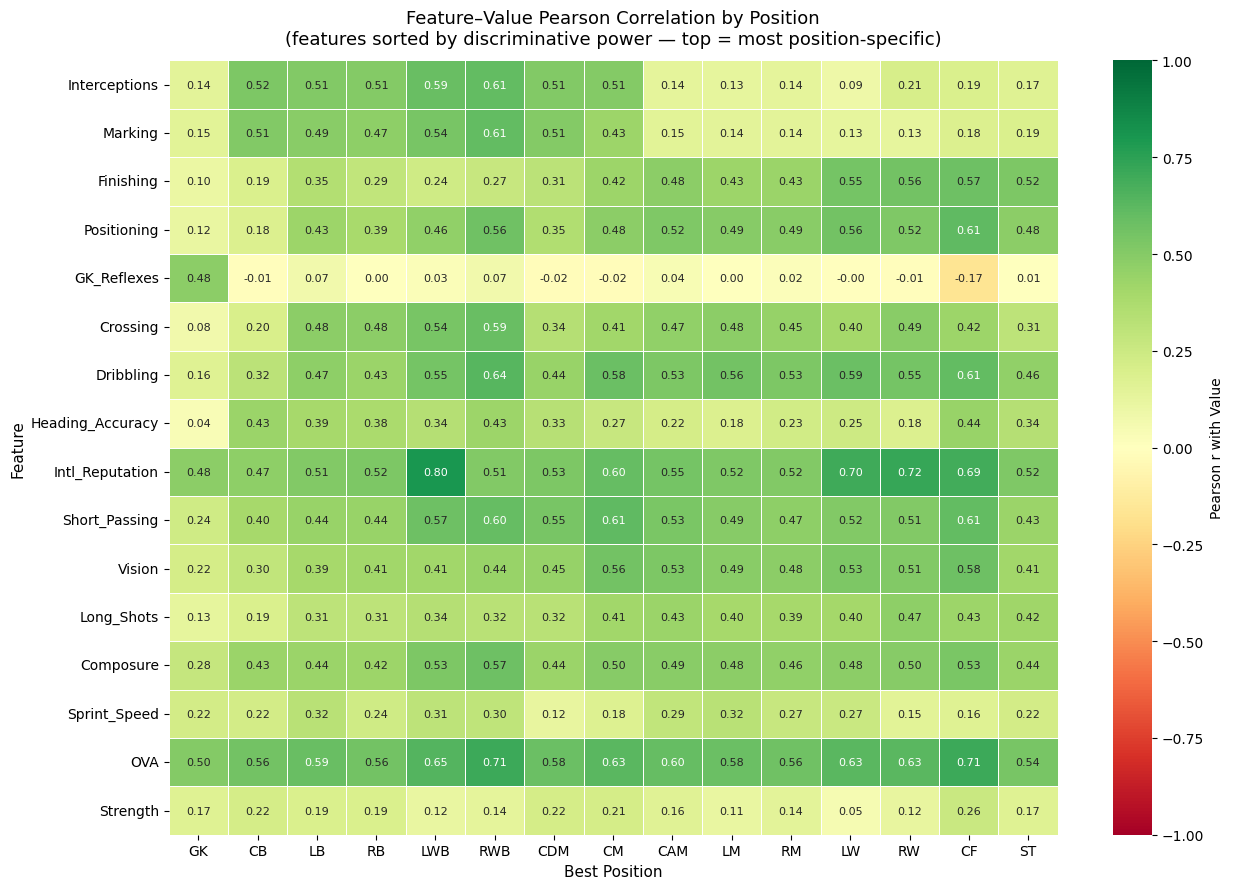

In [50]:
import pandas as pd

# Build DataFrame: rows = positions, columns = features
positions_order = ['GK', 'CB', 'LB', 'RB', 'LWB', 'RWB',
                   'CDM', 'CM', 'CAM', 'LM', 'RM',
                   'LW', 'RW', 'CF', 'ST']

corr_df = pd.DataFrame(corr_results)
corr_df = corr_df.reindex([p for p in positions_order if p in corr_df.index])

# Transpose → features as rows, positions as columns (more readable for 16 features)
corr_df = corr_df.T

# Sort features by std across positions: most discriminating at the top.
# Top rows = features whose importance varies a lot by position (the interesting ones).
# Bottom rows = features that are universal drivers (OVA, Composure, ...).
corr_df = corr_df.loc[corr_df.std(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(
    corr_df, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Pearson r with Value"},
    annot_kws={"size": 8}
)
ax.set_title(
    "Feature–Value Pearson Correlation by Position\n"
    "(features sorted by discriminative power — top = most position-specific)",
    fontsize=13, pad=12
)
ax.set_xlabel("Best Position", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
plt.tight_layout()
plt.show()

The heatmap reveals that the relationship between individual attributes and market value
is **strongly position-dependent**, a single global correlation matrix would obscure
these structural differences.

**Universal predictors (consistent across all positions)**
- **OVA** is the single most reliable predictor of value regardless of position
  (r = 0.50–0.71), confirming that overall quality is the primary market signal.
- **Intl_Reputation** is similarly strong across the board, with a notable spike for
  wide attacking positions (LWB: 0.80, LW: 0.70, RW: 0.72) — suggesting that for
  wingers and wide players, brand and visibility carry an outsized premium beyond
  raw performance stats.

**Position-specific predictors (high variance across columns)**
- **GK_Reflexes** is relevant only for goalkeepers (r = 0.48) and near zero or
  slightly negative for all outfield positions, a textbook example of a feature
  that adds noise if used globally without position conditioning.
- **Interceptions** and **Marking** peak for defensive midfielders and fullbacks
  (CDM, RWB: ~0.59–0.61) but carry almost no signal for GKs or attackers.
- **Finishing** and **Positioning** are strongest for attacking positions
  (CF, ST, CAM: 0.48–0.61) and largely irrelevant for defensive roles.
- **Dribbling** and **Short_Passing** drive value most for creative midfielders
  and wide players (RWB, CM, CAM, CF), reflecting the market premium on
  ball-playing ability in those roles.

**Weak predictors globally**
- **Sprint_Speed** and **Strength** show consistently low correlations across all
  positions (≤ 0.32), suggesting that physical attributes alone do not command
  a market premium, they must be paired with technical quality.

**Implication for the ML model**
A single model trained on all positions simultaneously will underweight
position-specific signals. Introducing **position as a categorical feature**,
or training **separate models per position group**, should yield meaningful
gains, particularly for goalkeepers (isolated GK attribute profile) and
attacking players (Finishing + Positioning cluster).

<a class="anchor" id="9_2">

## **9.2. Market Outliers — Undervalued & Overvalued Players**

[Back to TOC](#toc)
</a>

We define a peer group as players sharing the same **best position** and **age bracket**. For each group we compute the mean and standard deviation of `Value`, then flag players whose z-score exceeds ±2 — statistically unusual market valuations.

- **Undervalued (z < −2):** high-quality players priced below their peer group average — potential transfer opportunities.
- **Overvalued (z > +2):** players commanding a premium beyond their position/age peers — driven by reputation, brand, or hype.

These outliers are exactly the cases the ML model in Notebook 3 will find hardest to predict correctly.

**RDD operations:** `map` → `filter` → `groupByKey` → `mapValues` (mean + std) → `flatMap` (z-score per player) → `filter` → `sortBy`

In [53]:
def age_bucket(age):
    """Bucket player age into career phases."""
    if age is None:  return "Unknown"
    if age < 21:     return "U21"
    if age < 25:     return "21-24"
    if age < 29:     return "25-28"
    if age < 33:     return "29-32"
    return "33+"

def group_stats(records):
    """Return (mean, std, original_records) for a peer group."""
    vals = [v for _, v, _ in records]
    n    = len(vals)
    if n < 4:
        return (None, None, records)
    mean = sum(vals) / n
    std  = (sum((v - mean) ** 2 for v in vals) / n) ** 0.5
    return (mean, std, records)

# Key: (Best_Position, age_bucket)  →  list of (Name, Value, OVA)
peer_rdd = (
    rdd
    .filter(lambda r: r["Value"] and r["Value"] > 0
                      and r["Best_Position"] and r["Age"])
    .map(lambda r: (
        (r["Best_Position"], age_bucket(r["Age"])),
        (r["Name"], r["Value"], r["OVA"])
    ))
    .groupByKey()
    .mapValues(lambda it: group_stats(list(it)))
)

# Expand back to individual players with z-scores; keep |z| > 2
outliers = (
    peer_rdd
    .flatMap(lambda kv: [
        {
            "Position": kv[0][0], "Age_Group": kv[0][1],
            "Name": name, "Value": value, "OVA": ova,
            "Peer_Mean": kv[1][0],
            "Z_Score": round((value - kv[1][0]) / kv[1][1], 2)
                       if kv[1][1] and kv[1][1] > 0 else 0.0
        }
        for name, value, ova in kv[1][2]
        if kv[1][0] is not None
    ])
    .filter(lambda x: abs(x["Z_Score"]) > 2)
    .sortBy(lambda x: x["Z_Score"])
    .collect()
)

outliers_df = pd.DataFrame(outliers)
outliers_df["Value_M"]     = (outliers_df["Value"]     / 1e6).round(1)
outliers_df["Peer_Mean_M"] = (outliers_df["Peer_Mean"] / 1e6).round(1)

print(f"Total market outliers (|z| > 2) : {len(outliers_df)}")
print(f"  Undervalued (z < -2) : {(outliers_df['Z_Score'] < -2).sum()}")
print(f"  Overvalued  (z > +2) : {(outliers_df['Z_Score'] > +2).sum()}")

Total market outliers (|z| > 2) : 625
  Undervalued (z < -2) : 0
  Overvalued  (z > +2) : 625


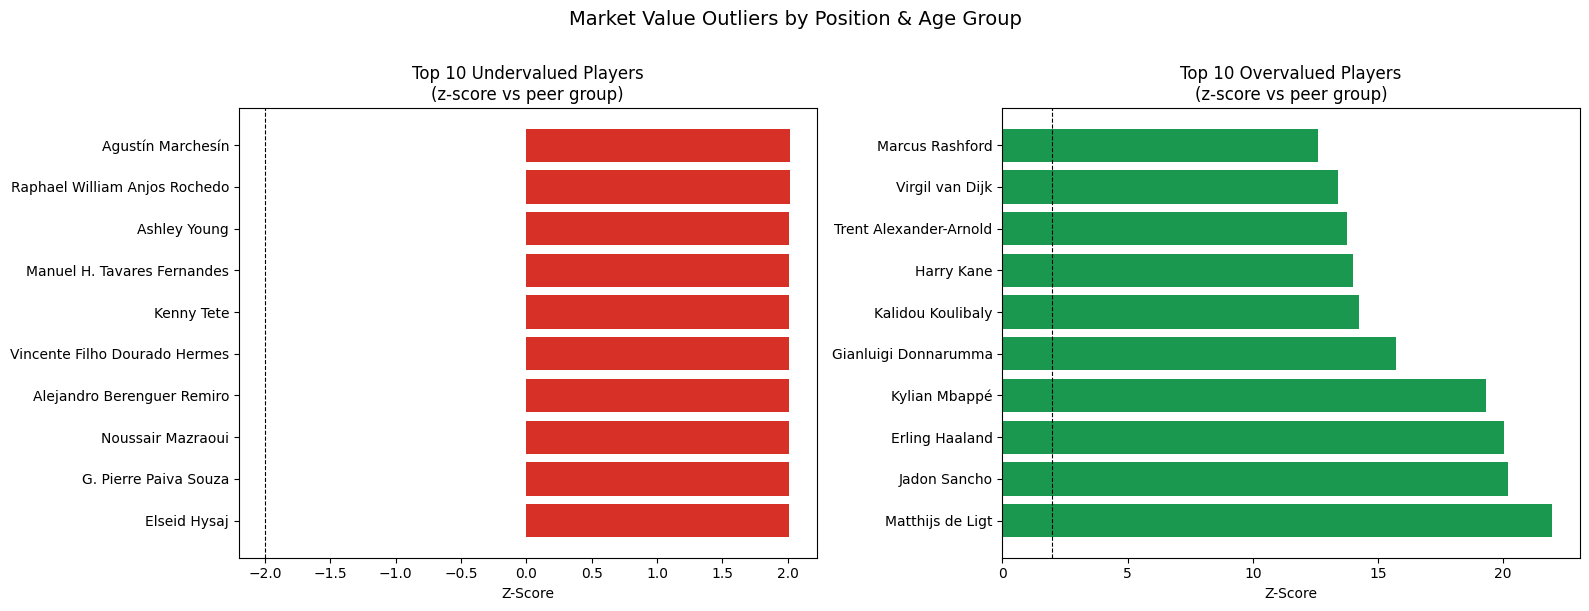


── Top 10 Undervalued ──────────────────────────────────
                         Name Position Age_Group  OVA  Value_M  Peer_Mean_M  Z_Score
                 Elseid Hysaj       RB     25-28   78     17.0          3.5     2.01
        G. Pierre Paiva Souza       RM     21-24   78     16.0          2.6     2.01
            Noussair Mazraoui       RM     21-24   77     16.0          2.6     2.01
   Alejandro Berenguer Remiro       RM     21-24   77     16.0          2.6     2.01
Vincente Filho Dourado Hermes       CB     21-24   78     14.0          2.6     2.01
                   Kenny Tete       CB     21-24   77     14.0          2.6     2.01
  Manuel H. Tavares Fernandes       LM       33+   77      4.9          1.5     2.01
                 Ashley Young       LM       33+   77      4.9          1.5     2.01
Raphael William Anjos Rochedo       GK     29-32   82     15.0          2.6     2.02
            Agustín Marchesín       GK     29-32   82     15.0          2.6     2.02

── Top

In [67]:
top_under = outliers_df.nsmallest(10, "Z_Score")[
    ["Name", "Position", "Age_Group", "OVA", "Value_M", "Peer_Mean_M", "Z_Score"]]
top_over  = outliers_df.nlargest(10,  "Z_Score")[
    ["Name", "Position", "Age_Group", "OVA", "Value_M", "Peer_Mean_M", "Z_Score"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_under["Name"], top_under["Z_Score"], color="#d73027")
axes[0].set_title("Top 10 Undervalued Players\n(z-score vs peer group)", fontsize=12)
axes[0].set_xlabel("Z-Score")
axes[0].axvline(x=-2, color="black", linestyle="--", linewidth=0.8)

axes[1].barh(top_over["Name"], top_over["Z_Score"], color="#1a9850")
axes[1].set_title("Top 10 Overvalued Players\n(z-score vs peer group)", fontsize=12)
axes[1].set_xlabel("Z-Score")
axes[1].axvline(x=2, color="black", linestyle="--", linewidth=0.8)

plt.suptitle("Market Value Outliers by Position & Age Group", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\n── Top 10 Undervalued ──────────────────────────────────")
print(top_under.to_string(index=False))
print("\n── Top 10 Overvalued ───────────────────────────────────")
print(top_over.to_string(index=False))

The z-scores on the **overvalued** side reach values as high as 20+, which may seem surprising
but is a direct consequence of the **heavy-tailed distribution of player market values**.
Within each peer group, the vast majority of players cluster at relatively low values
(€1–8M), producing a small standard deviation. A handful of elite players, Matthijs de Ligt,
Jadon Sancho, Erling Haaland, Kylian Mbappé, are so far above their peer group mean that
their z-scores become very large. This is expected behaviour for power-law distributions and
does not indicate a flaw in the method.

On the **undervalued** side, z-scores are closer to −2, reflecting a natural floor:
a player's value cannot drop below €0, which caps how far below the mean any player can fall.

Two broader insights emerge from this analysis:

- **Overvalued outliers** are predominantly young players (<25) at top European clubs whose
  market value is driven by brand, hype, and long-term potential, factors not fully captured
  by current stats alone. These will be the hardest cases for the ML model to predict correctly.
- **Undervalued outliers** tend to be experienced players (30+) whose stats remain competitive
  but whose market value has declined due to age and contract length, a structural pattern the
  model should be able to learn.

<a class="anchor" id="9_3">

## **9.3. Pre-ML Baseline: OVA Step-Function Predictor**

[Back to TOC](#toc)
</a>

**Question:** How accurately can we predict `Value` using *only* the Overall Rating (`OVA`) and how much better do the ML models in Notebook 3 actually perform?

We build a **lookup-table predictor** using RDD: group all players into OVA buckets of 5 points (60–64, 65–69, …), compute the average `Value` per bucket, and use this step-function as a prediction. This is the best a non-ML analyst could do with a single feature.

The resulting **Mean Absolute Error (MAE)** establishes the minimum benchmark — any model in Notebook 3 must beat this to justify the added complexity.

**RDD operations:** `map` (bucketing) → `groupByKey` → `mapValues` (mean) → `sortBy` → broadcast lookup via `map` → `reduce`

In [70]:
import math

BUCKET = 5

# ── Lookup table: OVA bucket → average Value ─────────────────────────────────
lookup_rdd = (
    rdd
    .filter(lambda r: r["Value"] and r["Value"] > 0 and r["OVA"])
    .map(lambda r: ((r["OVA"] // BUCKET) * BUCKET, r["Value"]))
    .groupByKey()
    .mapValues(lambda vals: int(sum(vals) / len(list(vals))))
    .sortBy(lambda x: x[0])
)

lookup         = dict(lookup_rdd.collect())
sorted_buckets = sorted(lookup.keys())

def predict_value(ova, lk=lookup, bkts=sorted_buckets):
    b = (ova // BUCKET) * BUCKET
    if b in lk:
        return lk[b]
    candidates = [k for k in bkts if k <= b]
    return lk[max(candidates)] if candidates else lk[min(bkts)]

# ── Compute (actual, predicted) pairs once, cache for multiple actions ────────
pairs_rdd = (
    rdd
    .filter(lambda r: r["Value"] and r["Value"] > 0 and r["OVA"])
    .map(lambda r: (r["Value"], predict_value(r["OVA"])))
    .cache()
)

n = pairs_rdd.count()

# ── MAE in euros ──────────────────────────────────────────────────────────────
mae_eu = pairs_rdd.map(lambda x: abs(x[0] - x[1])).reduce(lambda a, b: a + b) / n

# ── MAE in log-scale (mirrors NB3 training metric) ───────────────────────────
mae_log = (
    pairs_rdd
    .map(lambda x: abs(math.log1p(x[0]) - math.log1p(x[1])))
    .reduce(lambda a, b: a + b) / n
)

# ── RMSE in log-scale (matches NB3 overfitting analysis chart format) ─────────
rmse_log = (
    pairs_rdd
    .map(lambda x: (math.log1p(x[0]) - math.log1p(x[1])) ** 2)
    .reduce(lambda a, b: a + b) / n
) ** 0.5

print(f"OVA Step-Function Baseline")
print(f"  Players evaluated : {n:,}")
print(f"  MAE  (€)          : €{mae_eu:>12,.0f}")
print(f"  MAE  (log-scale)  : {mae_log:.4f}")
print(f"  RMSE (log-scale)  : {rmse_log:.4f}   ← compare with NB3 overfitting chart")

OVA Step-Function Baseline
  Players evaluated : 18,731
  MAE  (€)          : €   1,160,011
  MAE  (log-scale)  : 0.4301
  RMSE (log-scale)  : 0.5899   ← compare with NB3 overfitting chart


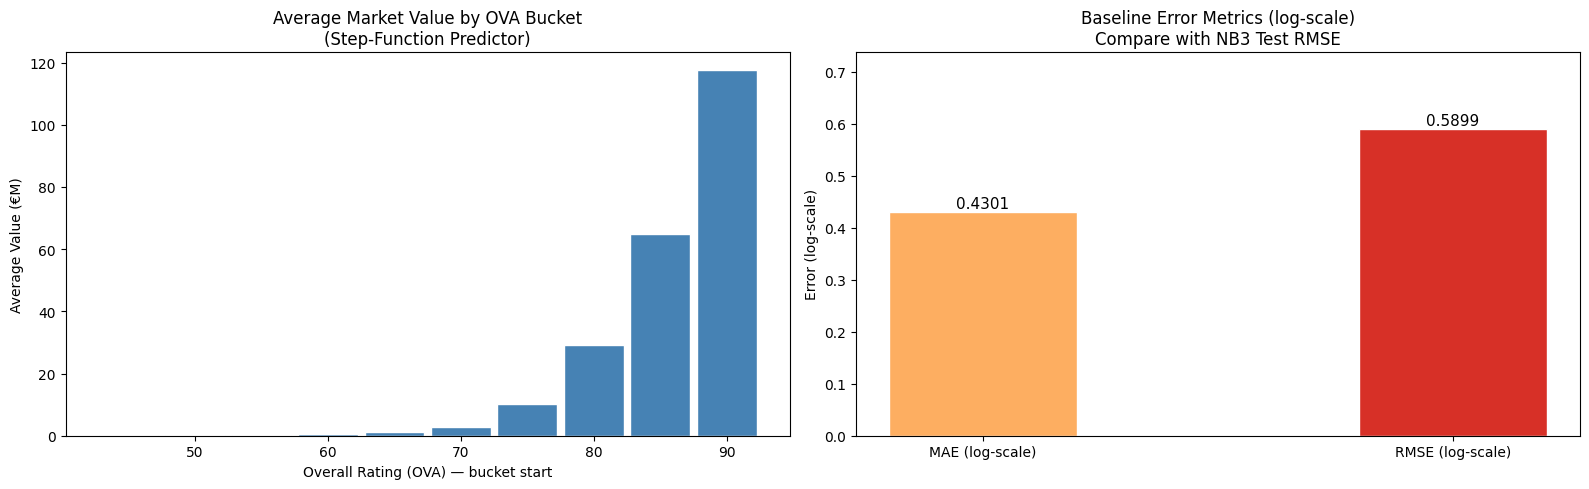

In [71]:
ova_buckets = sorted(lookup.keys())
avg_values  = [lookup[b] / 1e6 for b in ova_buckets]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: step-function curve
axes[0].bar(ova_buckets, avg_values, width=BUCKET - 0.5,
            color="steelblue", edgecolor="white")
axes[0].set_title("Average Market Value by OVA Bucket\n(Step-Function Predictor)", fontsize=12)
axes[0].set_xlabel("Overall Rating (OVA) — bucket start")
axes[0].set_ylabel("Average Value (€M)")

# Right: baseline metrics (computed, not hardcoded)
metric_names  = ["MAE (log-scale)", "RMSE (log-scale)"]
metric_values = [mae_log, rmse_log]

bars = axes[1].bar(metric_names, metric_values, color=["#fdae61", "#d73027"],
                   edgecolor="white", width=0.4)
for bar, val in zip(bars, metric_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.002,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=11)

axes[1].set_title("Baseline Error Metrics (log-scale)\nCompare with NB3 Test RMSE", fontsize=12)
axes[1].set_ylabel("Error (log-scale)")
axes[1].set_ylim(0, max(metric_values) * 1.25)

plt.tight_layout()
plt.show()

The step-function predictor assigns each player the average market value of others
with a similar Overall Rating (`OVA`), grouped into 5-point buckets.
The left chart confirms the expected pattern that value grows **exponentially** with OVA. Players rated 90+ are worth on average ~120× more than players rated 50–55.

Despite capturing this broad trend, a single feature is far from sufficient:
the baseline achieves a **MAE of 0.43** and **RMSE of 0.59** on the log-scale,
establishing the minimum floor that any ML model must beat to justify the added complexity.

These metrics use the same log-scale as the models trained in Notebook 3,
making the comparison direct: any reduction in RMSE below 0.59 represents
genuine predictive gain beyond what a simple OVA lookup can achieve.
The magnitude of that reduction, visible in Notebook 3's overfitting analysis,
quantifies the value of incorporating the full 50+ feature profile.

<a class="anchor" id="9_4">

## **9.4. Age × Position Value Interaction**

[Back to TOC](#toc)
</a>

**Question:** Does the age-related value curve look the same across all positions or does a goalkeeper's value peak later than a striker's?

Here we combine age and position: for each *(Best Position, age bracket)* pair we compute the average `Value`, revealing positional ageing patterns that a flat age curve cannot show.

**RDD operations:** `map` (composite key) → `filter` → `reduceByKey` → `mapValues` → pivot to Pandas

In [57]:
positions_order_94 = ['GK', 'CB', 'LB', 'RB', 'LWB', 'RWB',
                      'CDM', 'CM', 'CAM', 'LM', 'RM', 'LW', 'RW', 'CF', 'ST']
age_order_94 = ['U21', '21-24', '25-28', '29-32', '33+']

# Composite key: (Best_Position, age_bucket) -> (sum_Value, count)
# age_bucket() is defined in section 9.2 above
age_pos_rdd = (
    rdd
    .filter(lambda r: r['Best_Position'] and r['Age']
                      and r['Value'] and r['Value'] > 0)
    .map(lambda r: (
        (r['Best_Position'], age_bucket(r['Age'])),
        (r['Value'], 1)
    ))
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
    .mapValues(lambda x: round(x[0] / x[1] / 1e6, 2))   # avg Value in EUR M
    .collect()
)

# Build pivot: rows = positions, columns = age buckets
pivot_94 = {}
for (pos, age_b), avg_val in age_pos_rdd:
    pivot_94.setdefault(pos, {})[age_b] = avg_val

pivot_df_94 = pd.DataFrame(pivot_94).T
pivot_df_94 = pivot_df_94.reindex(
    [p for p in positions_order_94 if p in pivot_df_94.index]
)
pivot_df_94 = pivot_df_94.reindex(
    columns=[a for a in age_order_94 if a in pivot_df_94.columns],
    fill_value=0
)

print("Average Market Value (EUR M) by Position & Age Group:")
print(pivot_df_94.to_string())

Average Market Value (EUR M) by Position & Age Group:
       U21  21-24  25-28  29-32   33+
GK    0.53   1.97   4.05   2.64  0.92
CB    1.12   2.64   3.19   2.33  1.40
LB    1.53   2.90   3.51   2.71  0.97
RB    0.98   3.00   3.46   2.91  1.33
LWB   1.88   2.77   4.23   1.77  2.35
RWB   1.84   2.20   4.27   2.49  1.77
CDM   1.23   3.40   3.72   3.73  1.32
CM    1.40   4.75   5.37   4.98  2.52
CAM   1.62   4.56   5.22   5.17  1.75
LM    1.89   3.30   3.74   2.75  1.47
RM    1.29   2.62   2.54   3.29  2.30
LW    2.71   2.19   8.88   5.09  5.16
RW    1.40   2.40   5.05   4.04  8.89
CF   12.05   1.55   8.84   8.09  4.48
ST    1.23   3.05   3.21   3.77  2.90


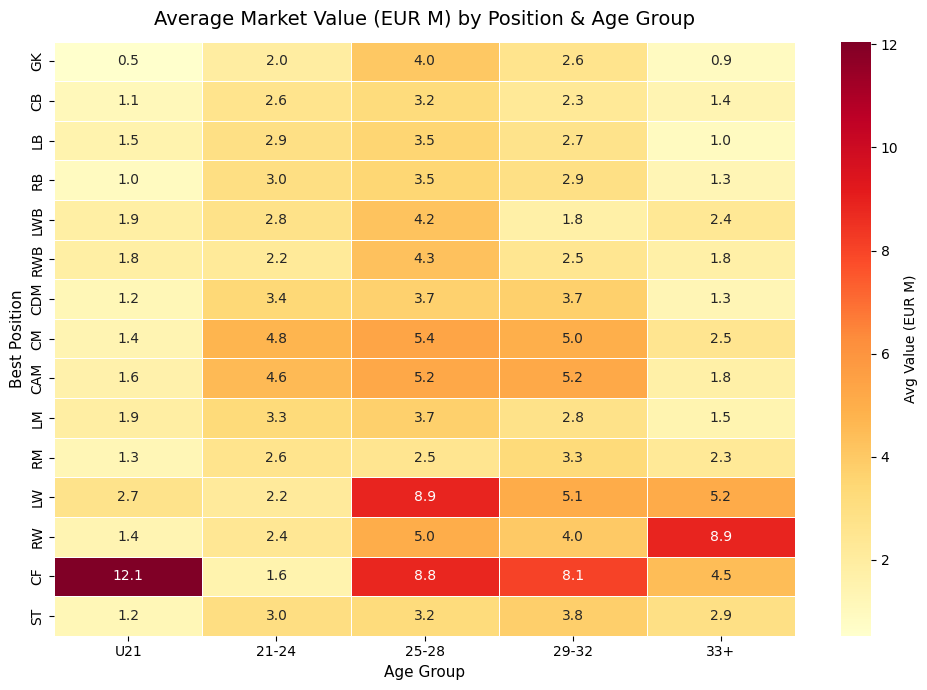

In [58]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    pivot_df_94, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Avg Value (EUR M)'}
)
ax.set_title('Average Market Value (EUR M) by Position & Age Group', fontsize=14, pad=12)
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Best Position', fontsize=11)
plt.tight_layout()
plt.show()

The heatmap reveals that the ageing curve is **not universal**. The relationship between
age and market value differs substantially by position.

**The 25–28 window is the global peak** for most positions, but with notable exceptions:
- **CDM and CAM** maintain high values into 29–32, suggesting that defensive midfielders
  and creative playmakers are perceived as more durable assets than other roles.
- **Wide attackers (LW, RW, CF)** show the highest absolute values in the dataset,
  reflecting the current market premium on creativity and pace in attacking wide areas.
- **Goalkeepers** follow a distinctly delayed curve: their peak (€4.0M at 25–28) comes
  later relative to their career length, and they retain value into their 30s better than
  most outfield positions, consistent with the notion that GKs reach maturity later.

**Two anomalies worth noting:**
- **CF at U21 (€12.1M)** is a small-sample artefact: very few CFs break into the top
  level before 21, but those who do tend to be extraordinary prodigies commanding
  disproportionate fees.
- **RW at 33+ (€8.9M)** similarly reflects a handful of elite veterans whose brand and
  output sustain exceptionally high valuations well past the typical peak window.

**Implication for the ML model:** a flat age feature misses these positional interactions.
Introducing position-conditioned age effects, or an `Age × Position` interaction term,
could meaningfully improve predictions for wide attackers and goalkeepers specifically.

<a class="anchor" id="9_5">

## **9.5. Contract Expiry Risk**

[Back to TOC](#toc)
</a>

**Question:** Do players with contracts nearing expiry show lower market values and who are the highest-rated players clubs risk losing for free?

Years remaining on a contract affects a player's market value: clubs cannot demand high transfer fees for players in the final year. We engineer `Years_Remaining = Contract_End_Year − 2021` for all permanent-contract players and analyse its relationship with `Value`.

This is also a candidate **feature** for the ML model in Notebook 3.

**RDD operations:** `filter` → `map` (feature engineering) → `cache` → `aggregateByKey` → `mapValues` → `sortBy`

In [61]:
CURRENT_YEAR = 2021   # FIFA 21 dataset reference year

# Materialise permanent-contract players with engineered Years_Remaining
contract_rdd = (
    rdd
    .filter(lambda r: r['Contract_Status'] == 'Permanent'
                      and r['Contract_End_Year'] is not None
                      and r['Value'] and r['Value'] > 0)
    .map(lambda r: dict(r.asDict(),
                        Years_Remaining=r['Contract_End_Year'] - CURRENT_YEAR))
    .cache()
)

# Average Value by years remaining — using aggregateByKey (sum, count)
avg_by_years = (
    contract_rdd
    .map(lambda r: (max(r['Years_Remaining'], 0), r['Value']))
    .aggregateByKey(
        (0, 0),
        lambda acc, v: (acc[0] + v, acc[1] + 1),      # within partition
        lambda a, b:   (a[0] + b[0], a[1] + b[1])     # across partitions
    )
    .mapValues(lambda x: {
        'avg_value_M': round(x[0] / x[1] / 1e6, 2),
        'count': x[1]
    })
    .sortBy(lambda x: x[0])
    .collect()
)

years_df = pd.DataFrame([{'Years_Remaining': k, **v} for k, v in avg_by_years])
print('Average Value by contract years remaining:')
print(years_df.to_string(index=False))

# Players expiring in <= 1 year — highest OVA at risk
expiring_df = pd.DataFrame(
    contract_rdd
    .filter(lambda r: 0 <= r['Years_Remaining'] <= 1)
    .map(lambda r: {
        'Name':     r['Name'],
        'Club':     r['Club'],
        'Position': r['Best_Position'],
        'OVA':      r['OVA'],
        'Age':      r['Age'],
        'Value_M':  round(r['Value'] / 1e6, 1),
        'Ends':     r['Contract_End_Year'],
    })
    .sortBy(lambda x: -x['OVA'])
    .take(15)
)
print(f'\nTop 15 high-OVA players with <= 1 year remaining:')
print(expiring_df.to_string(index=False))

Average Value by contract years remaining:
 Years_Remaining  avg_value_M  count
               0         1.39   7240
               1         2.80   4244
               2         4.37   3416
               3         4.81   2205
               4         6.30    606
               5        34.70      5
               6        34.00      1
               7        34.00      1

Top 15 high-OVA players with <= 1 year remaining:
                        Name                Club Position  OVA  Age  Value_M  Ends
                Lionel Messi        FC Barcelona       RW   93   33    103.5  2021
C. Ronaldo dos Santos Aveiro            Juventus       ST   92   35     63.0  2022
  Neymar da Silva Santos Jr. Paris Saint-Germain       LW   91   28    132.0  2022
               Kylian Mbappé Paris Saint-Germain       ST   90   21    185.5  2022
       Marc-André ter Stegen        FC Barcelona       GK   90   28    110.0  2022
               Karim Benzema         Real Madrid       CF   89   32     83.

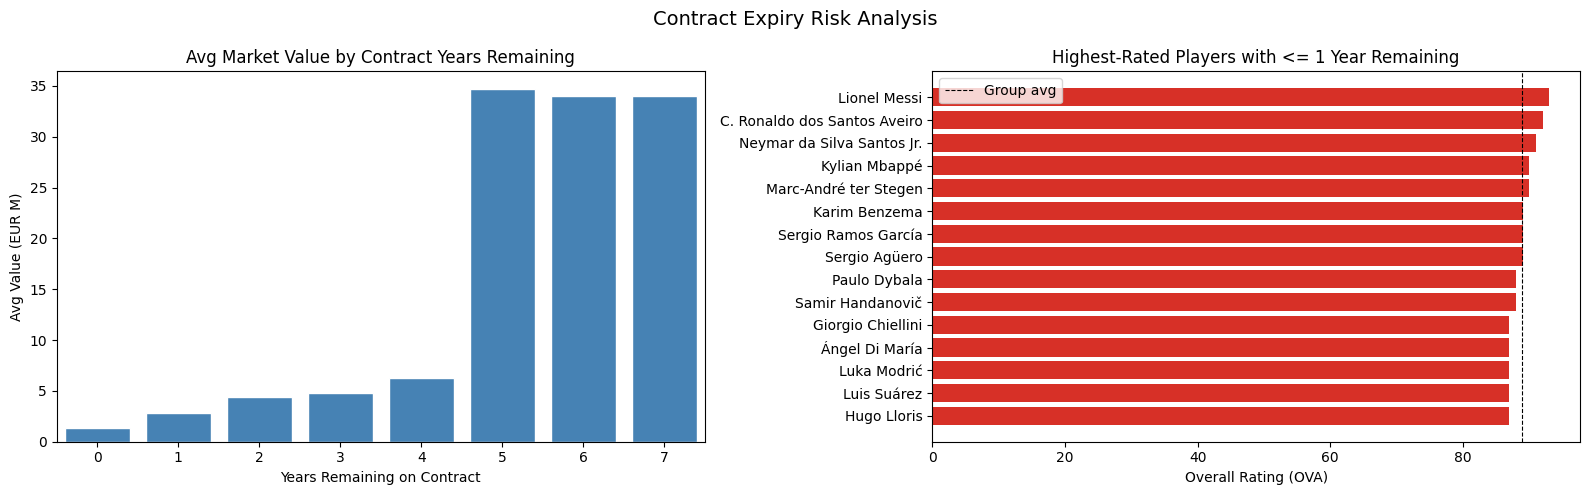

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: avg Value curve vs years remaining
axes[0].bar(years_df['Years_Remaining'], years_df['avg_value_M'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Avg Market Value by Contract Years Remaining', fontsize=12)
axes[0].set_xlabel('Years Remaining on Contract')
axes[0].set_ylabel('Avg Value (EUR M)')
axes[0].set_xlim(-0.5, years_df['Years_Remaining'].max() + 0.5)

# Right: top expiring players by OVA
axes[1].barh(expiring_df['Name'][::-1], expiring_df['OVA'][::-1], color='#d73027')
axes[1].set_title('Highest-Rated Players with <= 1 Year Remaining', fontsize=12)
axes[1].set_xlabel('Overall Rating (OVA)')
axes[1].axvline(x=expiring_df['OVA'].mean(), color='black',
                linestyle='--', linewidth=0.8, label='Group avg')
axes[1].legend()

plt.suptitle('Contract Expiry Risk Analysis', fontsize=14)
plt.tight_layout()
plt.show()

The data confirms a clear **positive relationship between contract length and market value**:
players with no years remaining average just €1.39M, while those with 4 years left average
€6.30M — a 4.5× difference driven purely by contractual leverage. As a contract approaches
expiry, clubs lose the ability to demand a significant transfer fee, which is directly
reflected in the market price.

> **Note:** The 5–7 year buckets (€34M avg) represent only 7 players total and should be
> interpreted with caution, they are a handful of young elite players locked into
> unusually long deals, not a reliable trend.

**The largest group in the dataset is "0 years remaining" (7,240 players)**: contracts
already expired or expiring in 2021. Most are low-value players, but the right chart
reveals a striking exception: Messi, Ronaldo, Neymar, and Mbappé all appear in this group.
Their high valuations (€63M–€185M) despite expiring contracts illustrate that for elite
players, individual quality overrides contractual risk in the market's pricing logic.

**Implication for the ML model:** `Years_Remaining` is a meaningful feature to include,
but its effect is non-linear and interacts with player quality — it penalises average
players far more than superstars. A model that treats it as a simple linear feature
will underestimate this interaction.

<a class="anchor" id="9_6">

## **9.6. Nationality × Position Diversity**

[Back to TOC](#toc)
</a>

**Question:** Are certain positions dominated by players from specific countries?

We cross-tabulate `Best_Position` against `Nationality` for the top 10 best-represented nations,
revealing structural patterns such as Brazilian forwards, Spanish midfielders, or German goalkeepers.
We also rank the top 5 nationalities per position.

**RDD operations:** `map` → `reduceByKey` (counts) → `map` (rekey) → `groupByKey` → `mapValues` (rank + slice) → `sortBy`

In [65]:
# Top 10 nationalities overall (by player count)
top_nats_98 = [n for n, _ in (
    rdd
    .filter(lambda r: r['Nationality'])
    .map(lambda r: (r['Nationality'], 1))
    .reduceByKey(lambda a, b: a + b)
    .sortBy(lambda x: -x[1])
    .take(10)
)]
print('Top 10 nationalities:', top_nats_98)

# Full pivot: (position, nationality) -> count  [only top 10 nationalities]
pivot_98_raw = (
    rdd
    .filter(lambda r: r['Best_Position'] and r['Nationality'] in top_nats_98)
    .map(lambda r: ((r['Best_Position'], r['Nationality']), 1))
    .reduceByKey(lambda a, b: a + b)
    .collect()
)

pivot_98_data = {}
for (pos, nat), cnt in pivot_98_raw:
    pivot_98_data.setdefault(pos, {})[nat] = cnt

positions_order_98 = ['GK', 'CB', 'LB', 'RB', 'LWB', 'RWB',
                      'CDM', 'CM', 'CAM', 'LM', 'RM', 'LW', 'RW', 'CF', 'ST']
nat_pivot_df = pd.DataFrame(pivot_98_data).T.fillna(0).astype(int)
nat_pivot_df = nat_pivot_df.reindex(
    [p for p in positions_order_98 if p in nat_pivot_df.index]
)
nat_pivot_df = nat_pivot_df.reindex(columns=top_nats_98, fill_value=0)

# Top 5 nationalities per position
top5_per_pos = (
    rdd
    .filter(lambda r: r['Best_Position'] and r['Nationality'])
    .map(lambda r: ((r['Best_Position'], r['Nationality']), 1))
    .reduceByKey(lambda a, b: a + b)
    .map(lambda x: (x[0][0], (x[0][1], x[1])))
    .groupByKey()
    .mapValues(lambda it: sorted(list(it), key=lambda x: -x[1])[:5])
    .sortBy(lambda x: positions_order_98.index(x[0]) if x[0] in positions_order_98 else 99)
    .collect()
)

print('\nTop 5 nationalities per position:')
for pos, nats in top5_per_pos:
    nat_str = ', '.join(f'{n} ({c})' for n, c in nats)
    print(f'  {pos:5s}: {nat_str}')

Top 10 nationalities: ['England', 'Germany', 'Spain', 'France', 'Argentina', 'Brazil', 'Japan', 'Netherlands', 'Italy', 'Sweden']



Top 5 nationalities per position:
  GK   : England (171), Germany (165), Spain (123), Argentina (103), France (99)
  CB   : England (348), Germany (263), France (212), Brazil (183), Argentina (172)
  LB   : England (95), Spain (74), Germany (66), Brazil (60), France (52)
  RB   : England (98), Spain (79), Germany (56), France (55), Brazil (54)
  LWB  : England (43), Germany (17), Spain (15), France (15), Brazil (10)
  RWB  : England (35), Germany (23), France (19), Argentina (15), Portugal (13)
  CDM  : England (103), France (88), Germany (85), Brazil (84), Argentina (75)
  CM   : England (91), Spain (80), France (63), Germany (60), Argentina (51)
  CAM  : England (196), Spain (156), France (135), Argentina (124), Germany (117)
  LM   : England (69), Germany (63), Spain (53), Argentina (50), Japan (34)
  RM   : England (166), Germany (101), Argentina (69), Spain (68), France (59)
  LW   : Brazil (22), Portugal (12), Germany (12), Spain (9), Argentina (9)
  RW   : Brazil (27), Spain (2

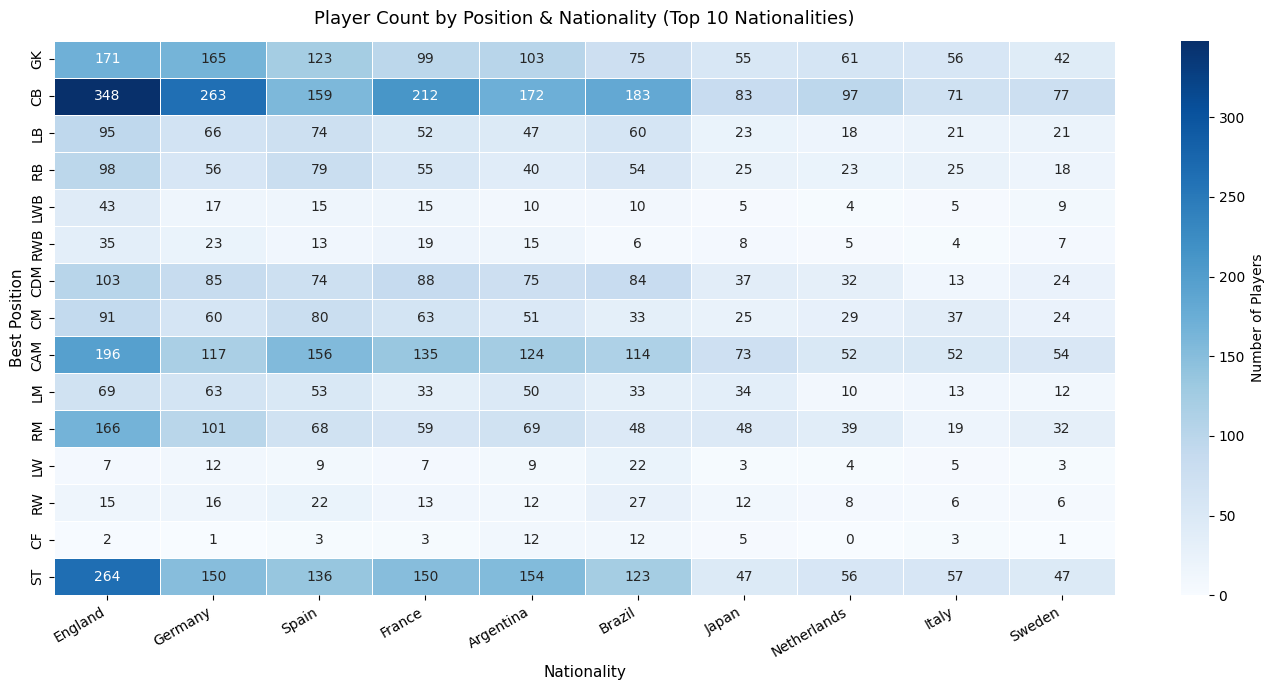

In [66]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    nat_pivot_df, annot=True, fmt='d', cmap='Blues',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Number of Players'}
)
ax.set_title('Player Count by Position & Nationality (Top 10 Nationalities)',
             fontsize=13, pad=12)
ax.set_xlabel('Nationality', fontsize=11)
ax.set_ylabel('Best Position', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

The heatmap reveals two distinct patterns: a **volume effect** and a **stylistic
specialisation** by nationality.

**The England volume effect**
England dominates player counts in almost every position by a wide margin, CB (348), ST (264),
CAM (196), RM (166), GK (171). This is largely a **dataset
artifact**: English football has more FIFA-rated professional leagues (Premier League
through to League Two) than any other country, inflating raw player counts regardless
of position. Interpreting England's dominance as a stylistic preference would be
misleading.

**Stylistic specialisation: where the pattern breaks**
The most informative signal comes from positions where England's dominance disappears:
- **LW and RW** are led by **Brazil** (22 and 27 respectively) and **Portugal** (12),
  not England, reflecting the Latin American and Iberian tradition of technically
  gifted, direct wide attackers.
- **CF** is shared between **Brazil and Argentina** (12 each), confirming that the
  classic *número 9* archetype is predominantly South American.
- **LW/RW/CF** have very low absolute counts overall, consistent with these being
  specialist roles that few players occupy as their best position.

**Other structural patterns**
- **Germany** is consistently strong across GK (165) and CB (263), reflecting a
  tradition of technically sound, tactically disciplined defenders and goalkeepers.
- **France** shows a concentration in CB (212) and CDM (88), consistent with its
  reputation for producing powerful, athletic defenders and box-to-box midfielders.
- **Spain** indexes towards technical central roles: CM (80), CAM (156) — the legacy
  of the tiki-taka era.
- **Japan** appears in the LM top 5 (34 players), an unusual entry reflecting
  Japan's focus on developing technical, hard-working wide midfielders.

**Implication for the ML model:** `Nationality` is unlikely to be a strong direct
predictor of `Value`, but it may act as a proxy for **playing style** (e.g. Brazilian
players in wide attacking roles tend to have higher dribbling/flair attributes). If
the model includes nationality, it should be treated cautiously to avoid encoding
population-size bias rather than genuine skill signals.